# Klasifikasi Prediksi Resiko Penyakit Jantung /n ## Menggunakan SVM, XGBoost, dan Random Forest

**Nama Mata Kuliah :** Pembelajaran Mesin  
**Kelas             :** A Informatika  
**Dataset           :** Heart Disease Prediction — Kaggle  
**Link Dataset      :** https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction  
**Jumlah Data       :** 5.568 baris × 19 kolom

---

## 1. Import Library

In [ ]:
!pip install xgboost imbalanced-learn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.under_sampling import RandomUnderSampler

print('✅ Semua library berhasil diimport!')
print(f'   Numpy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')

✅ Semua library berhasil diimport!
   Numpy   : 2.0.2
   Pandas  : 2.2.2


---
## 2. Data Understanding
### 2.1 Load Dataset

In [ ]:
# ============================================================
# OPSI A: Upload file CSV (Google Colab) — DISARANKAN
# ============================================================
from google.colab import files
uploaded = files.upload()   # pilih heart_disease_prediction.csv
df = pd.read_csv(list(uploaded.keys())[0])

# ============================================================
# OPSI B: Jika file sudah ada di direktori yang sama
# ============================================================
# df = pd.read_csv('heart_disease_prediction.csv')

print(f'✅ Dataset berhasil dimuat!')
print(f'   Shape  : {df.shape[0]} baris × {df.shape[1]} kolom')
df.head(10)

Saving heart_disease_prediction.csv to heart_disease_prediction (1).csv
✅ Dataset berhasil dimuat!
   Shape  : 5568 baris × 19 kolom


,taking_bp_meds,taking_cholesterol_meds,age,sex,race_ethnicity,education,poverty_income_ratio,taking_insulin,taking_diabetes_pills,told_prediabetes,told_stroke,family_history_heart_attack,diabetes,smoking_ever,smoking_current,physically_active,hypertension,high_cholesterol,heart_disease
0,1,0,66.0,2.0,4.0,2.0,0.82,0,0,0,0,0,0,1,0,1,1,0,0
1,1,1,66.0,2.0,6.0,1.0,1.63,0,0,0,0,0,0,0,0,1,1,1,0
2,1,0,75.0,2.0,4.0,4.0,0.41,0,0,1,1,0,0,1,1,1,1,0,0
3,0,0,56.0,1.0,6.0,5.0,5.00,0,0,0,0,1,0,0,0,1,0,1,0
4,0,0,67.0,1.0,3.0,3.0,2.65,0,0,0,0,0,0,1,1,1,0,0,0
5,0,0,54.0,2.0,4.0,4.0,1.86,1,0,0,0,0,1,1,0,0,0,1,0
6,0,1,71.0,1.0,7.0,3.0,1.56,0,0,0,0,1,0,1,1,1,0,1,1
7,0,0,61.0,1.0,6.0,5.0,5.00,0,0,0,0,0,0,1,0,1,0,0,0
8,0,0,22.0,1.0,3.0,3.0,1.49,0,0,0,0,1,0,1,1,0,0,0,0
9,1,0,45.0,1.0,4.0,3.0,1.18,0,0,0,0,1,0,0,0,1,1,0,0


### 2.2 Informasi Dataset

In [ ]:
print('=' * 65)
print('INFORMASI DATASET')
print('=' * 65)
print(f'Sumber  : Kaggle — Heart Disease Prediction')
print(f'Link    : https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction')
print(f'Baris   : {df.shape[0]}')
print(f'Kolom   : {df.shape[1]}')
print()
df.info()

INFORMASI DATASET
Sumber  : Kaggle — Heart Disease Prediction
Link    : https://www.kaggle.com/datasets/akrambelbakhouche/heart-disease-prediction
Baris   : 5568
Kolom   : 19

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5568 entries, 0 to 5567
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   taking_bp_meds               5568 non-null   int64  
 1   taking_cholesterol_meds      5568 non-null   int64  
 2   age                          5568 non-null   float64
 3   sex                          5568 non-null   float64
 4   race_ethnicity               5568 non-null   float64
 5   education                    5568 non-null   float64
 6   poverty_income_ratio         5568 non-null   float64
 7   taking_insulin               5568 non-null   int64  
 8   taking_diabetes_pills        5568 non-null   int64  
 9   told_prediabetes             5568 non-null   int64  
 10  told_stroke     

In [ ]:
print('=' * 65)
print('DESKRIPSI FITUR / VARIABEL')
print('=' * 65)
feature_desc = {
    'taking_bp_meds'             : 'Sedang mengonsumsi obat tekanan darah (0=Tidak, 1=Ya)',
    'taking_cholesterol_meds'    : 'Sedang mengonsumsi obat kolesterol (0=Tidak, 1=Ya)',
    'age'                        : 'Usia pasien (tahun)',
    'sex'                        : 'Jenis kelamin (1=Laki-laki, 2=Perempuan)',
    'race_ethnicity'             : 'Ras/Etnis pasien (kode kategori)',
    'education'                  : 'Tingkat pendidikan (kode kategori)',
    'poverty_income_ratio'       : 'Rasio pendapatan terhadap garis kemiskinan',
    'taking_insulin'             : 'Sedang menggunakan insulin (0=Tidak, 1=Ya)',
    'taking_diabetes_pills'      : 'Mengonsumsi obat diabetes (0=Tidak, 1=Ya)',
    'told_prediabetes'           : 'Pernah didiagnosis prediabetes (0=Tidak, 1=Ya)',
    'told_stroke'                : 'Pernah didiagnosis stroke (0=Tidak, 1=Ya)',
    'family_history_heart_attack': 'Riwayat serangan jantung dalam keluarga (0=Tidak, 1=Ya)',
    'diabetes'                   : 'Terdiagnosis diabetes (0=Tidak, 1=Ya)',
    'smoking_ever'               : 'Pernah merokok (0=Tidak, 1=Ya)',
    'smoking_current'            : 'Saat ini merokok (0=Tidak, 1=Ya)',
    'physically_active'          : 'Aktif secara fisik (0=Tidak, 1=Ya)',
    'hypertension'               : 'Terdiagnosis hipertensi (0=Tidak, 1=Ya)',
    'high_cholesterol'           : 'Kolesterol tinggi (0=Tidak, 1=Ya)',
    'heart_disease'              : '🎯 TARGET — Penyakit jantung (0=Tidak, 1=Ya)'
}
for feat, desc in feature_desc.items():
    print(f'  {feat:35} : {desc}')

DESKRIPSI FITUR / VARIABEL
  taking_bp_meds                      : Sedang mengonsumsi obat tekanan darah (0=Tidak, 1=Ya)
  taking_cholesterol_meds             : Sedang mengonsumsi obat kolesterol (0=Tidak, 1=Ya)
  age                                 : Usia pasien (tahun)
  sex                                 : Jenis kelamin (1=Laki-laki, 2=Perempuan)
  race_ethnicity                      : Ras/Etnis pasien (kode kategori)
  education                           : Tingkat pendidikan (kode kategori)
  poverty_income_ratio                : Rasio pendapatan terhadap garis kemiskinan
  taking_insulin                      : Sedang menggunakan insulin (0=Tidak, 1=Ya)
  taking_diabetes_pills               : Mengonsumsi obat diabetes (0=Tidak, 1=Ya)
  told_prediabetes                    : Pernah didiagnosis prediabetes (0=Tidak, 1=Ya)
  told_stroke                         : Pernah didiagnosis stroke (0=Tidak, 1=Ya)
  family_history_heart_attack         : Riwayat serangan jantung dalam keluarga (0

In [ ]:
print('\n📊 STATISTIK DESKRIPTIF')
print('=' * 65)
df.describe().T


📊 STATISTIK DESKRIPTIF


,count,mean,std,min,25%,50%,75%,max
taking_bp_meds,5568.0,0.295977,0.456522,0.000000e+00,0.00,0.00,1.00,1.0
taking_cholesterol_meds,5568.0,0.215517,0.411218,0.000000e+00,0.00,0.00,0.00,1.0
age,5568.0,51.501796,17.813899,2.000000e+01,36.00,53.00,66.00,80.0
sex,5568.0,1.514907,0.499823,1.000000e+00,1.00,2.00,2.00,2.0
race_ethnicity,5568.0,3.509339,1.640247,1.000000e+00,3.00,3.00,4.00,7.0
education,5568.0,3.514907,1.214602,1.000000e+00,3.00,4.00,4.00,5.0
poverty_income_ratio,5568.0,2.496519,1.490829,5.397605e-79,1.35,2.14,3.65,5.0
taking_insulin,5568.0,0.043822,0.204717,0.000000e+00,0.00,0.00,0.00,1.0
taking_diabetes_pills,5568.0,0.128233,0.334379,0.000000e+00,0.00,0.00,0.00,1.0
told_prediabetes,5568.0,0.102550,0.303398,0.000000e+00,0.00,0.00,0.00,1.0


In [ ]:
print('📊 DISTRIBUSI KELAS TARGET (heart_disease)')
print('=' * 50)
counts = df['heart_disease'].value_counts()
pct    = df['heart_disease'].value_counts(normalize=True) * 100
print(f'  Kelas 0 (Tidak Sakit Jantung) : {counts[0]:>5} sampel  ({pct[0]:.2f}%)')
print(f'  Kelas 1 (Sakit Jantung)       : {counts[1]:>5} sampel  ({pct[1]:.2f}%)')
print(f'\n  ⚠️  Dataset TIDAK SEIMBANG → akan ditangani dengan Random Undersampling')

📊 DISTRIBUSI KELAS TARGET (heart_disease)
  Kelas 0 (Tidak Sakit Jantung) :  5041 sampel  (90.54%)
  Kelas 1 (Sakit Jantung)       :   527 sampel  (9.46%)

  ⚠️  Dataset TIDAK SEIMBANG → akan ditangani dengan Random Undersampling


---
## 3. Data Preprocessing
### 3.1 Cek Missing Values

In [ ]:
print('📋 CEK MISSING VALUES')
print('=' * 45)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

📋 CEK MISSING VALUES
                             Jumlah Missing  Persentase (%)
taking_bp_meds                            0             0.0
taking_cholesterol_meds                   0             0.0
age                                       0             0.0
sex                                       0             0.0
race_ethnicity                            0             0.0
education                                 0             0.0
poverty_income_ratio                      0             0.0
taking_insulin                            0             0.0
taking_diabetes_pills                     0             0.0
told_prediabetes                          0             0.0
told_stroke                               0             0.0
family_history_heart_attack               0             0.0
diabetes                                  0             0.0
smoking_ever                              0             0.0
smoking_current                           0             0.0
physically_active  

In [ ]:
cols_missing = df.columns[df.isnull().any()].tolist()
if cols_missing:
    for col in cols_missing:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f'  ✅ Kolom "{col}" diimputasi dengan median = {med}')
else:
    print('  ✅ Tidak ada missing values — tidak perlu imputasi.')
print(f'\n  Total missing setelah imputasi: {df.isnull().sum().sum()}')

  ✅ Tidak ada missing values — tidak perlu imputasi.

  Total missing setelah imputasi: 0


### 3.2 Penanganan Outlier (IQR Capping)

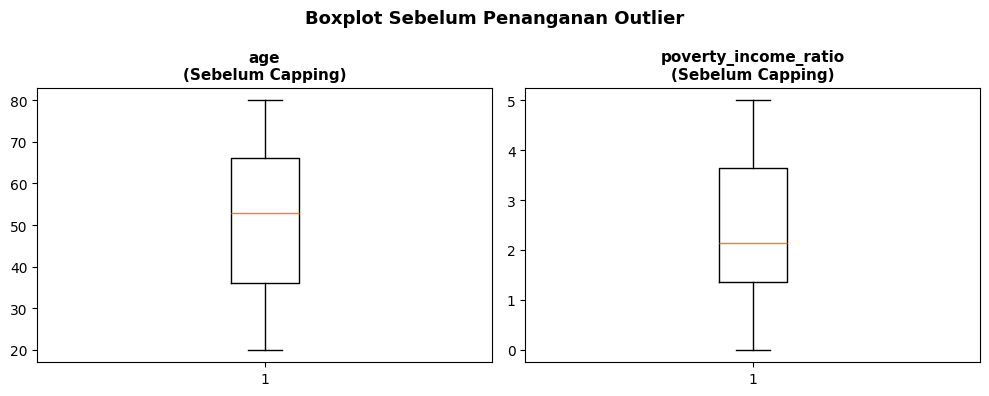

In [ ]:
continuous_cols = ['age', 'poverty_income_ratio']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(f'{col}\n(Sebelum Capping)', fontsize=11, fontweight='bold')
plt.suptitle('Boxplot Sebelum Penanganan Outlier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
df_clean = df.copy()
outlier_report = []

for col in continuous_cols:
    Q1    = df_clean[col].quantile(0.25)
    Q3    = df_clean[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_report.append({
        'Fitur': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'Lower Bound': round(lower,2), 'Upper Bound': round(upper,2),
        'Jumlah Outlier': n_out
    })
    df_clean[col] = df_clean[col].clip(lower, upper)

print('📊 LAPORAN OUTLIER (IQR Capping / Winsorization)')
print('=' * 70)
print(pd.DataFrame(outlier_report).to_string(index=False))
print(f'\nShape setelah penanganan outlier: {df_clean.shape}')

📊 LAPORAN OUTLIER (IQR Capping / Winsorization)
               Fitur    Q1    Q3  Lower Bound  Upper Bound  Jumlah Outlier
                 age 36.00 66.00         -9.0        111.0               0
poverty_income_ratio  1.35  3.65         -2.1          7.1               0

Shape setelah penanganan outlier: (5568, 19)


### 3.3 Pemisahan Fitur & Target

In [ ]:
X = df_clean.drop('heart_disease', axis=1)
y = df_clean['heart_disease']

print(f'Shape X (fitur)  : {X.shape}')
print(f'Shape y (target) : {y.shape}')
print(f'Fitur            : {X.columns.tolist()}')

Shape X (fitur)  : (5568, 18)
Shape y (target) : (5568,)
Fitur            : ['taking_bp_meds', 'taking_cholesterol_meds', 'age', 'sex', 'race_ethnicity', 'education', 'poverty_income_ratio', 'taking_insulin', 'taking_diabetes_pills', 'told_prediabetes', 'told_stroke', 'family_history_heart_attack', 'diabetes', 'smoking_ever', 'smoking_current', 'physically_active', 'hypertension', 'high_cholesterol']


### 3.4 Penanganan Imbalanced Data (Random Undersampling)

> **Catatan penting:** Undersampling dilakukan **sebelum** normalisasi pada data resampled
> untuk menghindari data leakage. Scaler di-fit hanya pada data training split.

📊 DISTRIBUSI SEBELUM UNDERSAMPLING
heart_disease
0    5041
1     527
Name: count, dtype: int64
Rasio: heart_disease
0    90.54
1     9.46
Name: proportion, dtype: float64

📊 DISTRIBUSI SETELAH RANDOM UNDERSAMPLING
heart_disease
0    527
1    527
Name: count, dtype: int64

Shape setelah Undersampling : X=(1054, 18), y=(1054,)


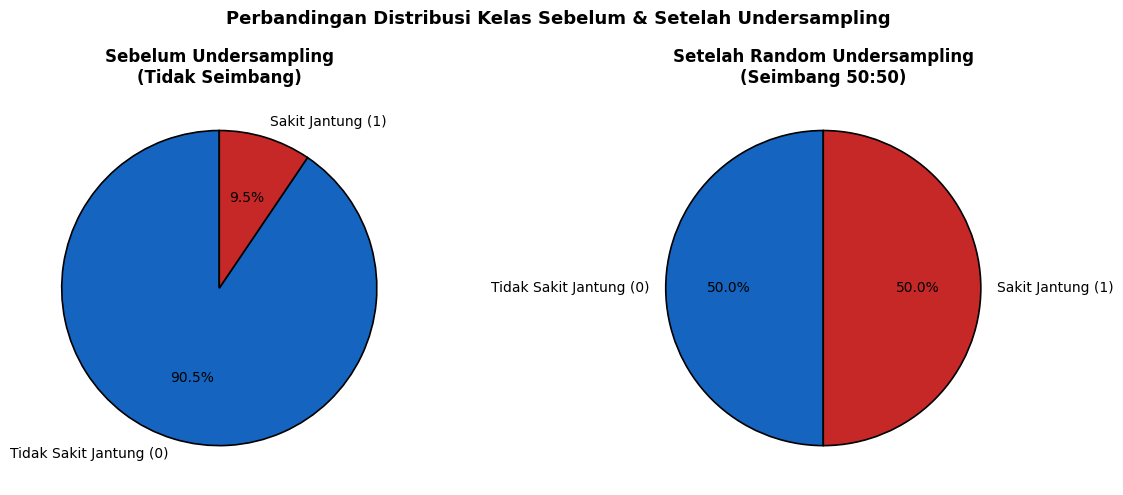

✅ Masing-masing kelas kini berjumlah 527 sampel (seimbang 50:50).
   Normalisasi StandardScaler akan diterapkan PER SPLIT (fit hanya di train)
   untuk menghindari data leakage.


In [ ]:
print('📊 DISTRIBUSI SEBELUM UNDERSAMPLING')
print(y.value_counts())
print(f'Rasio: {(y.value_counts(normalize=True)*100).round(2)}')

# ── Random Undersampling tanpa normalisasi dulu ──────────────────────────
# Tujuan: kurangi kelas mayoritas (0) agar seimbang dengan minoritas (1)
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X, y)   # input RAW (belum dinormalisasi)

print('\n📊 DISTRIBUSI SETELAH RANDOM UNDERSAMPLING')
y_rus_s = pd.Series(y_rus)
print(y_rus_s.value_counts())
print(f'\nShape setelah Undersampling : X={X_rus.shape}, y={y_rus.shape}')

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
label_names = ['Tidak Sakit Jantung (0)', 'Sakit Jantung (1)']
colors_pie  = ['#1565C0', '#C62828']

before = y.value_counts()
axes[0].pie(before.values, labels=label_names, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[0].set_title('Sebelum Undersampling\n(Tidak Seimbang)', fontsize=12, fontweight='bold')

after = y_rus_s.value_counts()
axes[1].pie(after.values, labels=label_names, autopct='%1.1f%%',
            colors=colors_pie, startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.2})
axes[1].set_title('Setelah Random Undersampling\n(Seimbang 50:50)', fontsize=12, fontweight='bold')

plt.suptitle('Perbandingan Distribusi Kelas Sebelum & Setelah Undersampling',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'✅ Masing-masing kelas kini berjumlah {after[0]} sampel (seimbang 50:50).')
print('   Normalisasi StandardScaler akan diterapkan PER SPLIT (fit hanya di train)')
print('   untuk menghindari data leakage.')

---
## 4. Exploratory Data Analysis (EDA)
### 4.1 Distribusi Seluruh Fitur

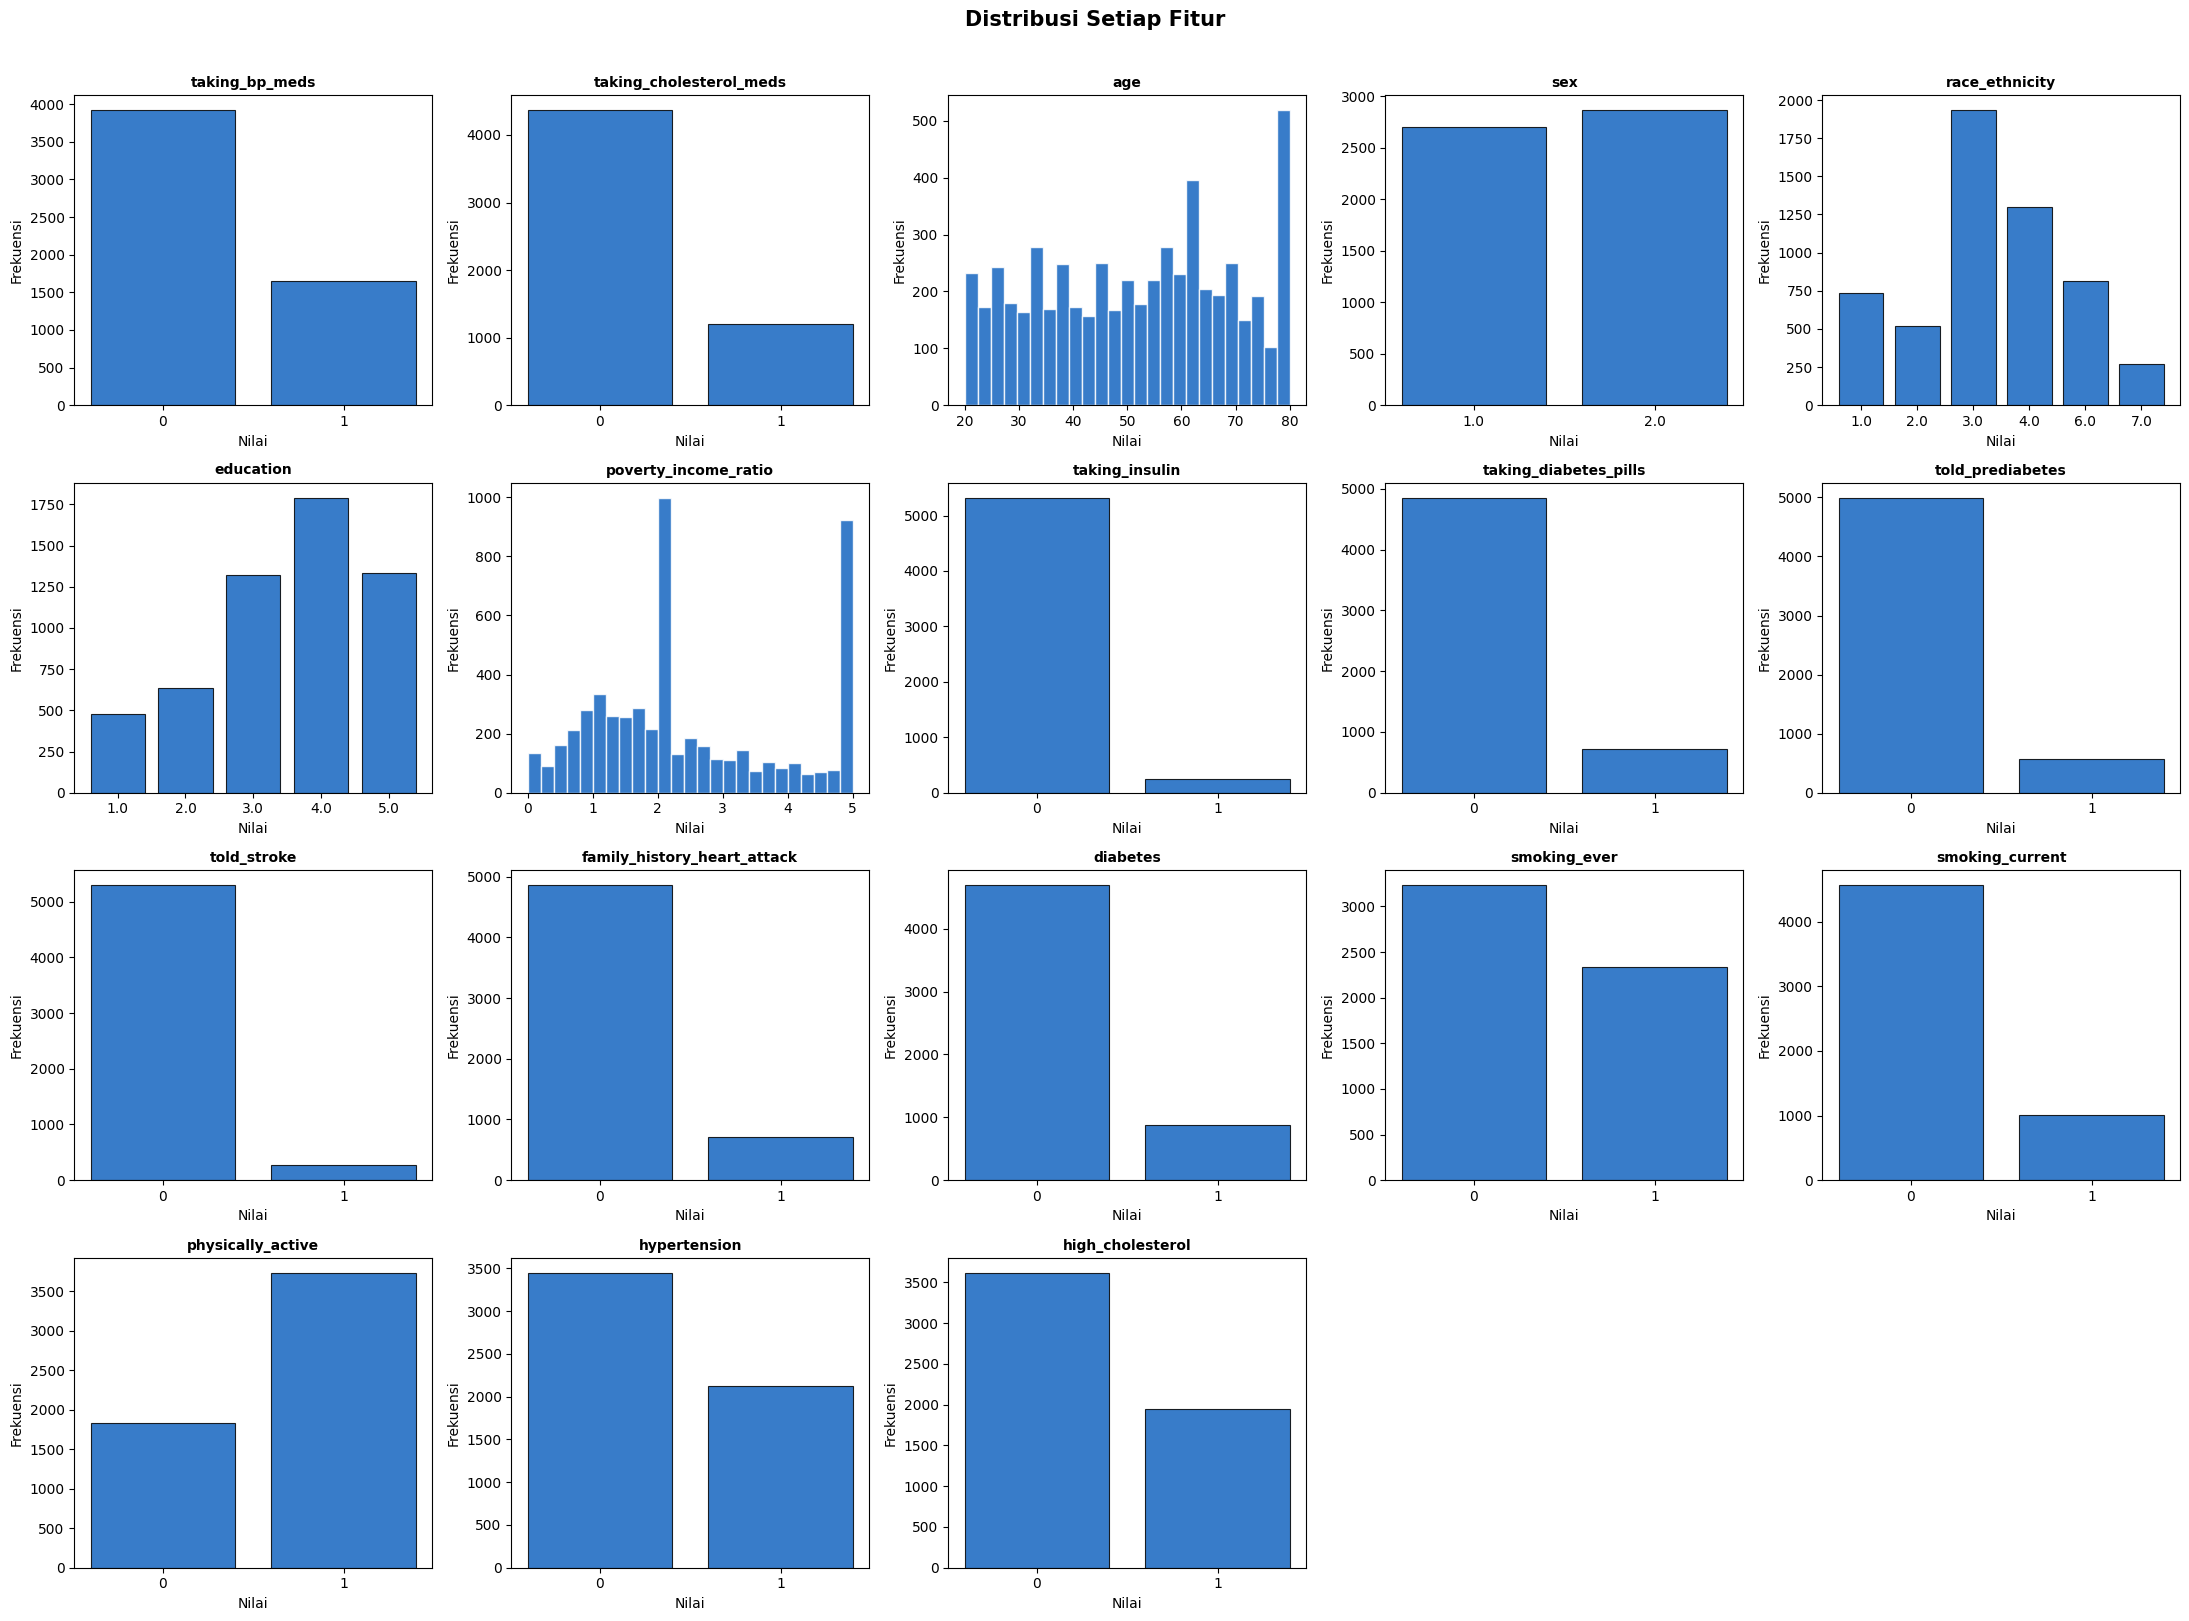

In [ ]:
all_feat_cols = X.columns.tolist()
n_cols = 5
n_rows = -(-len(all_feat_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(all_feat_cols):
    unique_vals = df_clean[col].nunique()
    if unique_vals <= 6:
        vc = df_clean[col].value_counts().sort_index()
        axes[i].bar(vc.index.astype(str), vc.values,
                    color='#1565C0', edgecolor='black', linewidth=0.8, alpha=0.85)
        axes[i].set_ylabel('Frekuensi')
    else:
        axes[i].hist(df_clean[col], bins=25, color='#1565C0',
                     edgecolor='white', alpha=0.85)
        axes[i].set_ylabel('Frekuensi')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Nilai')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Setiap Fitur', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Distribusi Target

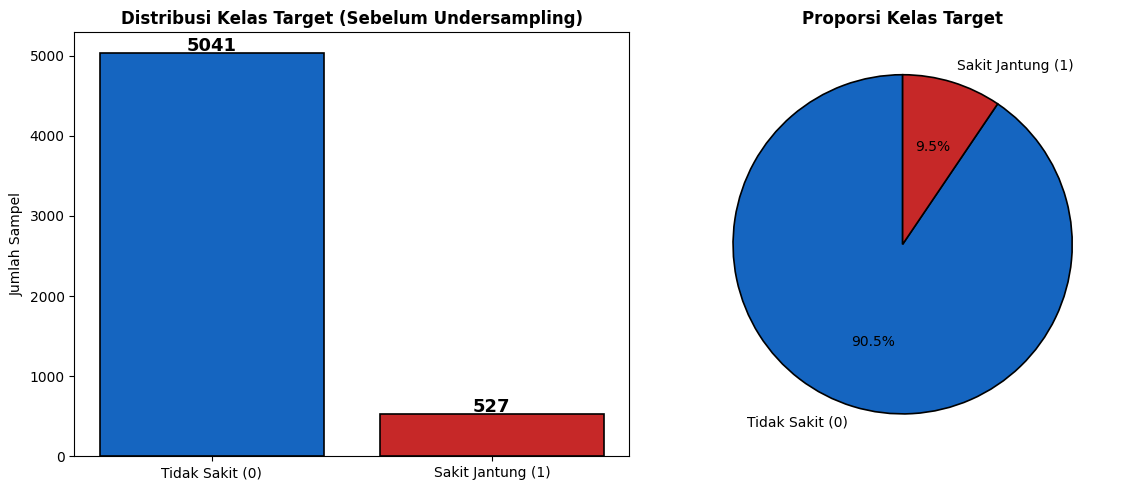

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = y.value_counts()

bars = axes[0].bar(['Tidak Sakit (0)', 'Sakit Jantung (1)'],
                   counts.values, color=['#1565C0', '#C62828'],
                   edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(val), ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('Distribusi Kelas Target (Sebelum Undersampling)',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].pie(counts.values, labels=['Tidak Sakit (0)', 'Sakit Jantung (1)'],
            autopct='%1.1f%%', colors=['#1565C0', '#C62828'],
            startangle=90, wedgeprops={'edgecolor':'black','linewidth':1.2})
axes[1].set_title('Proporsi Kelas Target', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Heatmap Korelasi

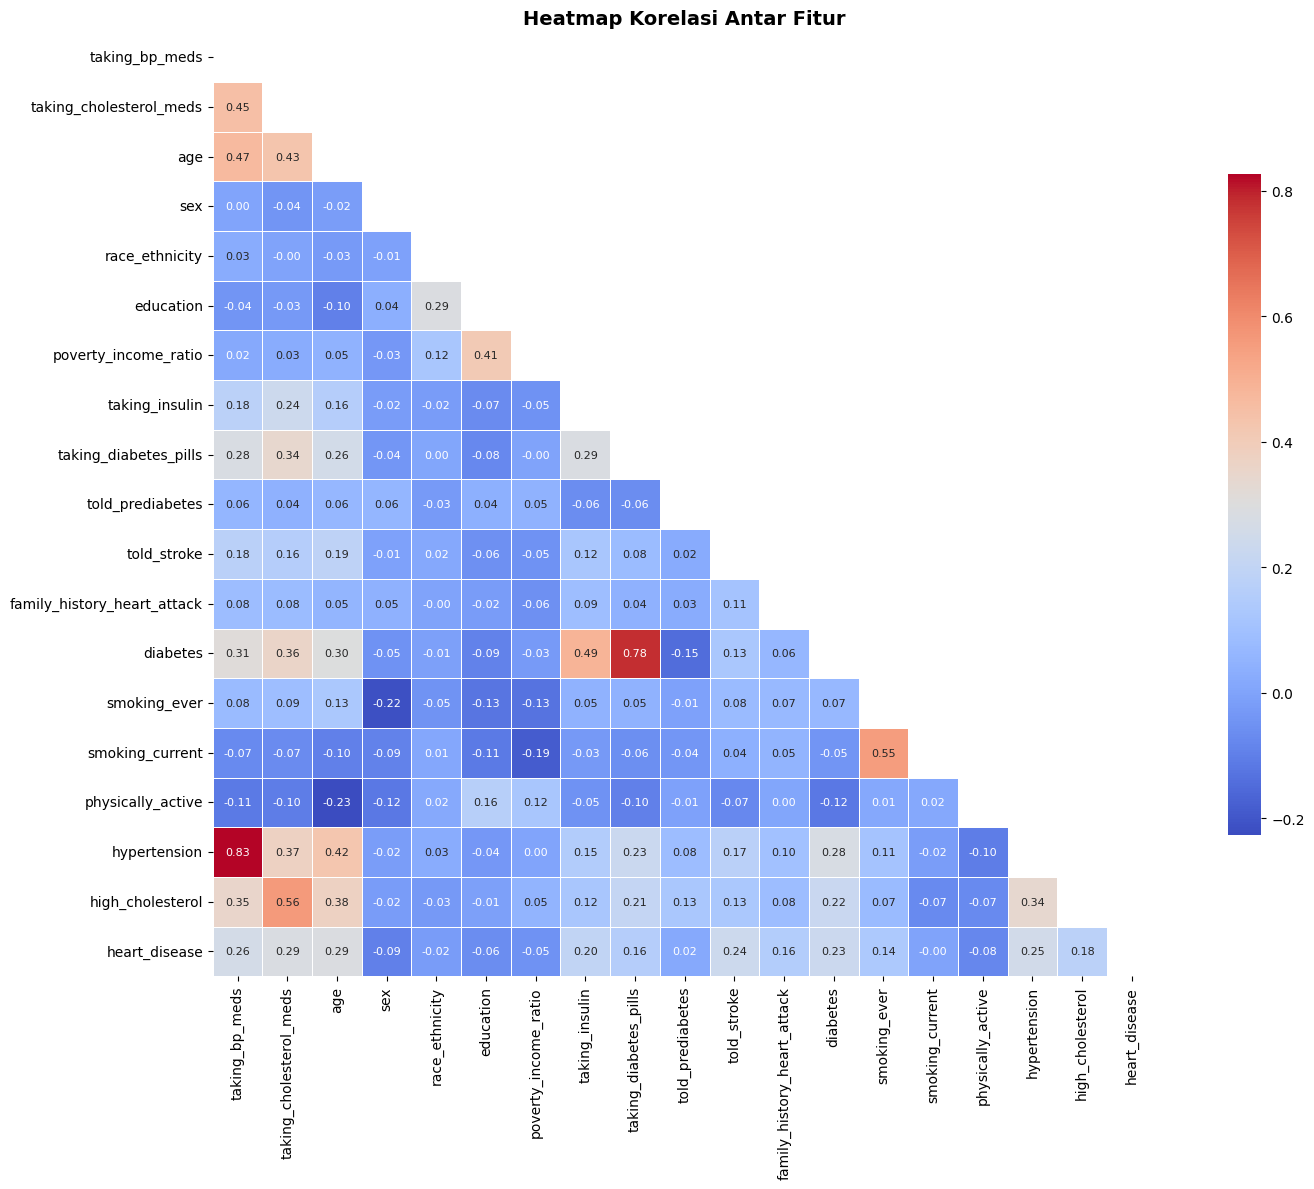

In [ ]:
plt.figure(figsize=(16, 12))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

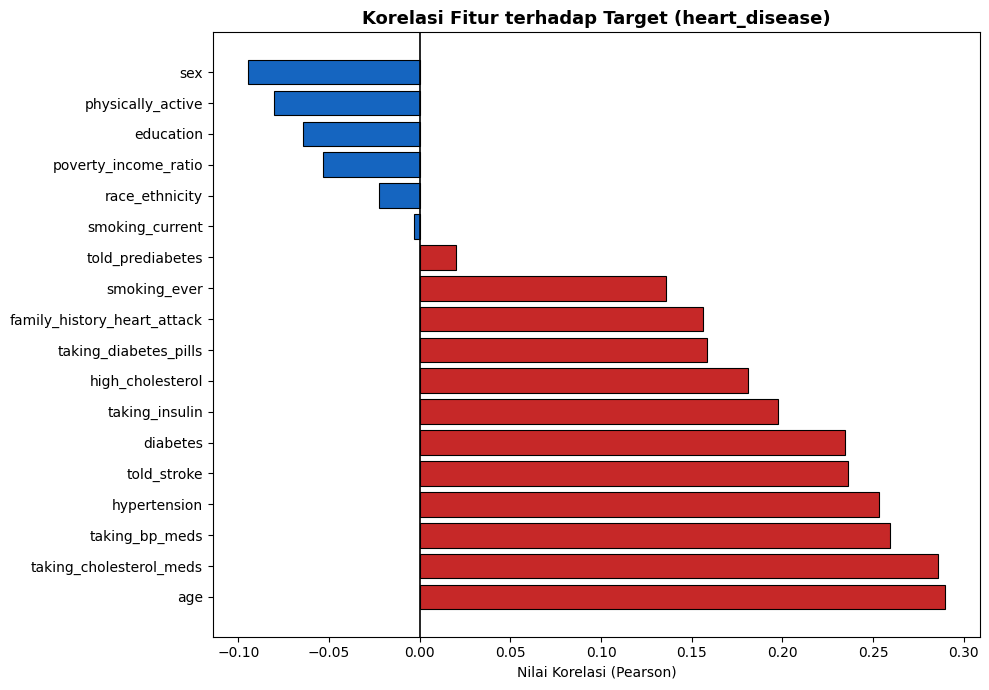

Top 5 fitur berkorelasi POSITIF dengan target:
age                        0.2897
taking_cholesterol_meds    0.2856
taking_bp_meds             0.2594
hypertension               0.2533
told_stroke                0.2363
Name: heart_disease, dtype: float64

Top 5 fitur berkorelasi NEGATIF dengan target:
race_ethnicity         -0.0222
poverty_income_ratio   -0.0533
education              -0.0643
physically_active      -0.0804
sex                    -0.0950
Name: heart_disease, dtype: float64


In [ ]:
target_corr = df_clean.corr()['heart_disease'].drop('heart_disease').sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors_bar = ['#C62828' if v > 0 else '#1565C0' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values,
         color=colors_bar, edgecolor='black', linewidth=0.8)
plt.axvline(x=0, color='black', linewidth=1.2)
plt.title('Korelasi Fitur terhadap Target (heart_disease)',
          fontsize=13, fontweight='bold')
plt.xlabel('Nilai Korelasi (Pearson)')
plt.tight_layout()
plt.show()

print('Top 5 fitur berkorelasi POSITIF dengan target:')
print(target_corr.head(5).round(4))
print('\nTop 5 fitur berkorelasi NEGATIF dengan target:')
print(target_corr.tail(5).round(4))

### 4.4 Distribusi Fitur Penting per Kelas Target

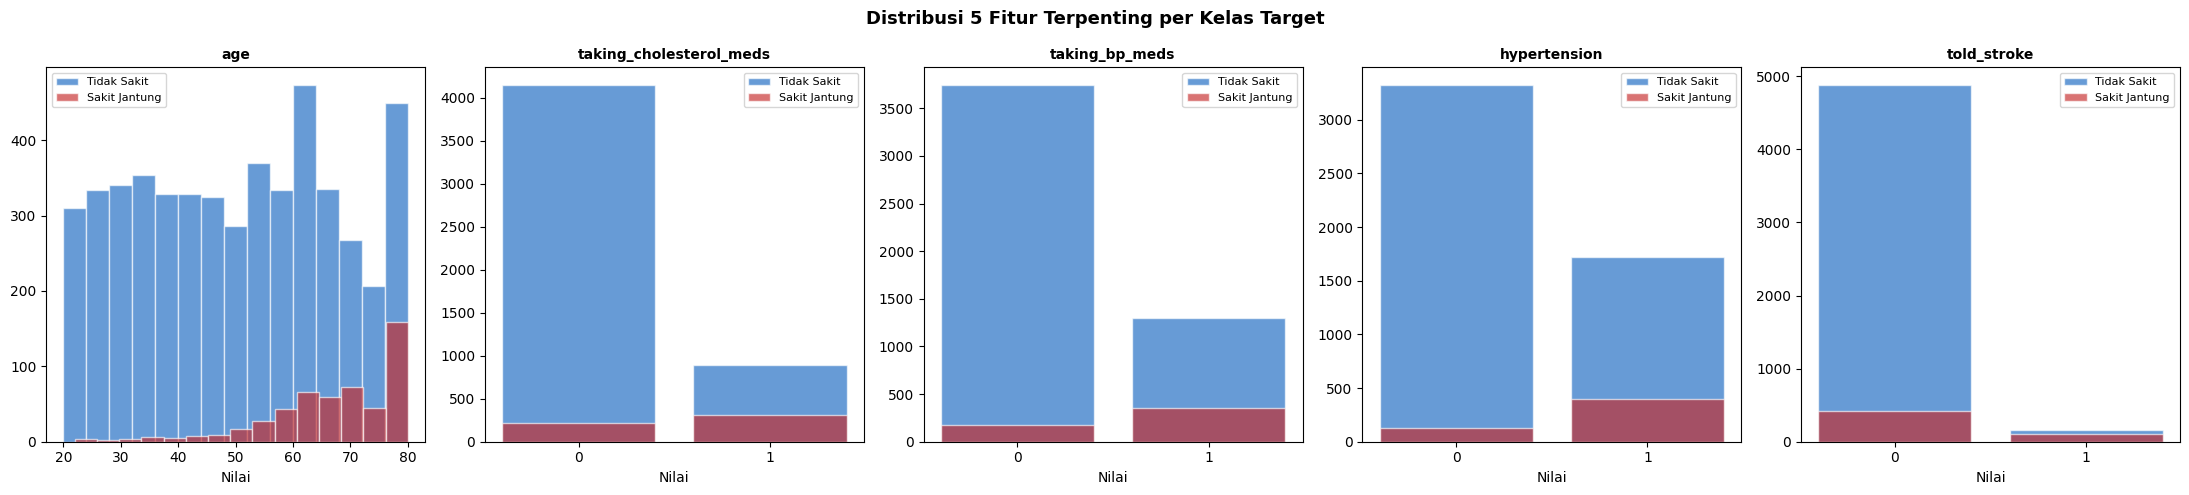

In [ ]:
top5 = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, feat in enumerate(top5):
    for cls, color, lbl in [(0,'#1565C0','Tidak Sakit'),(1,'#C62828','Sakit Jantung')]:
        data = df_clean[df_clean['heart_disease']==cls][feat]
        if data.nunique() <= 6:
            vc = data.value_counts().sort_index()
            axes[i].bar([str(v) for v in vc.index], vc.values,
                        alpha=0.65, color=color, label=lbl, edgecolor='white')
        else:
            axes[i].hist(data, bins=15, alpha=0.65, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Nilai')

plt.suptitle('Distribusi 5 Fitur Terpenting per Kelas Target',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Data Splitting
### 5.1 Tiga Kombinasi Rasio Split

> **Normalisasi diterapkan di dalam setiap split** (fit hanya pada data training,
> transform pada data testing) untuk mencegah data leakage.

In [ ]:
split_configs = [
    {'test_size': 0.30, 'label': '70:30 (Train:Test)'},
    {'test_size': 0.20, 'label': '80:20 (Train:Test)'},
    {'test_size': 0.10, 'label': '90:10 (Train:Test)'},
]

splits = []
print('=' * 65)
print('PEMBAGIAN DATA + NORMALISASI PER SPLIT (anti data leakage)')
print('=' * 65)

for cfg in split_configs:
    # Split data RAW (sebelum normalisasi)
    X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
        X_rus, y_rus,
        test_size=cfg['test_size'],
        random_state=42,
        stratify=y_rus
    )

    # Fit scaler HANYA pada data training, transform keduanya
    scaler_split = StandardScaler()
    X_tr = scaler_split.fit_transform(X_tr_raw)
    X_te = scaler_split.transform(X_te_raw)

    splits.append({
        'label'        : cfg['label'],
        'X_train'      : X_tr,
        'X_test'       : X_te,
        'y_train'      : y_tr,
        'y_test'       : y_te,
        'scaler'       : scaler_split,   # simpan scaler per split untuk inference
        'X_train_raw'  : X_tr_raw
    })
    print(f"\n{cfg['label']}")
    print(f'  Train : {len(X_tr):>5} sampel  |  Test : {len(X_te):>5} sampel')
    print(f'  Distribusi Train : {dict(pd.Series(y_tr).value_counts().sort_index())}')
    print(f'  Distribusi Test  : {dict(pd.Series(y_te).value_counts().sort_index())}')

# Simpan scaler split 80:20 untuk inference
scaler_inference = splits[1]['scaler']
print('\n✅ Setiap split memiliki scaler sendiri yang di-fit hanya pada data train.')

PEMBAGIAN DATA + NORMALISASI PER SPLIT (anti data leakage)

70:30 (Train:Test)
  Train :   737 sampel  |  Test :   317 sampel
  Distribusi Train : {0: np.int64(368), 1: np.int64(369)}
  Distribusi Test  : {0: np.int64(159), 1: np.int64(158)}

80:20 (Train:Test)
  Train :   843 sampel  |  Test :   211 sampel
  Distribusi Train : {0: np.int64(421), 1: np.int64(422)}
  Distribusi Test  : {0: np.int64(106), 1: np.int64(105)}

90:10 (Train:Test)
  Train :   948 sampel  |  Test :   106 sampel
  Distribusi Train : {0: np.int64(474), 1: np.int64(474)}
  Distribusi Test  : {0: np.int64(53), 1: np.int64(53)}

✅ Setiap split memiliki scaler sendiri yang di-fit hanya pada data train.


---
## 6. Hyperparameter Tuning (GridSearchCV — 5-Fold CV)

**Strategi anti-overfitting yang diterapkan:**
- Tuning menggunakan **5-Fold Stratified Cross Validation**
- RF: `max_depth` dibatasi, `min_samples_leaf` diperbesar untuk regularisasi
- XGB: ditambah **`reg_alpha` (L1) dan `reg_lambda` (L2)** untuk regularisasi, serta `max_depth` kecil
- SVM: parameter `C` yang lebih kecil untuk margin yang lebih besar (lebih general)

### 6.1 Tuning SVM

In [ ]:
X_train_tune = splits[1]['X_train']
y_train_tune = splits[1]['y_train']
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('🔍 HYPERPARAMETER TUNING — SVM')
print('=' * 55)
print('  Fokus: kernel rbf dengan C moderat untuk generalisasi baik')

# PERBAIKAN: C lebih kecil = margin lebih besar = lebih general
svm_param_grid = {
    'C'     : [0.01, 0.1, 1, 10, 50],
    'kernel': ['rbf', 'linear'],
    'gamma' : ['scale', 'auto', 0.01, 0.1]
}

svm_gs = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_param_grid,
    cv=cv5, scoring='f1_weighted', n_jobs=-1, verbose=1
)
svm_gs.fit(X_train_tune, y_train_tune)

best_svm_params = svm_gs.best_params_
print(f'\n✅ Best Parameters SVM : {best_svm_params}')
print(f'✅ Best CV F1 SVM      : {svm_gs.best_score_*100:.2f}%')

🔍 HYPERPARAMETER TUNING — SVM
  Fokus: kernel rbf dengan C moderat untuk generalisasi baik
Fitting 5 folds for each of 40 candidates, totalling 200 fits

✅ Best Parameters SVM : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Best CV F1 SVM      : 79.29%


### 6.2 Tuning Random Forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print('🔍 FAST HYPERPARAMETER TUNING — RANDOM FOREST')
print('=' * 55)

rf_param_dist = {
    'n_estimators'     : [100, 150, 200],
    'max_depth'        : [6, 8, 10, 12],      # tetap dibatasi
    'min_samples_split': [10, 20],            # tidak terlalu banyak variasi
    'min_samples_leaf' : [5, 10],             # anti overfit
    'max_features'     : ['sqrt'],
    'max_samples'      : [0.7, 0.8]
}

rf_rs = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        bootstrap=True
    ),
    param_distributions=rf_param_dist,
    n_iter=25,              # 🔥 cuma 25 percobaan (super cepat)
    cv=cv5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_rs.fit(X_train_tune, y_train_tune)

best_rf_params = rf_rs.best_params_

print(f'\n✅ Best Parameters RF : {best_rf_params}')
print(f'✅ Best CV F1 RF      : {rf_rs.best_score_*100:.2f}%')

🔍 FAST HYPERPARAMETER TUNING — RANDOM FOREST
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Best Parameters RF : {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 8}
✅ Best CV F1 RF      : 79.39%


### 6.3 Tuning XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import numpy as np

print('🔍 FAST HYPERPARAMETER TUNING — XGBOOST')
print('=' * 55)

xgb_param_dist = {
    'n_estimators'    : [100, 150, 200],
    'max_depth'       : [3, 4, 5],
    'learning_rate'   : [0.01, 0.05, 0.1],
    'subsample'       : [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma'           : [0.1, 0.2],
    'min_child_weight': [5, 10],
    'reg_alpha'       : [0.1, 0.5],
    'reg_lambda'      : [1.0, 2.0]
}

xgb_rs = RandomizedSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method='hist'   # 🔥 lebih cepat
    ),
    param_distributions=xgb_param_dist,
    n_iter=30,              # 🔥 cukup 30 percobaan (cepat banget)
    cv=cv5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_rs.fit(X_train_tune, y_train_tune)

best_xgb_params = xgb_rs.best_params_

print(f'\n✅ Best Parameters XGB : {best_xgb_params}')
print(f'✅ Best CV F1 XGB      : {xgb_rs.best_score_*100:.2f}%')

🔍 FAST HYPERPARAMETER TUNING — XGBOOST
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best Parameters XGB : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
✅ Best CV F1 XGB      : 79.77%


### 6.4 Ringkasan Hasil Tuning

In [ ]:
print('=' * 65)
print('RINGKASAN HYPERPARAMETER TUNING (scoring = f1_weighted, 5-Fold CV)')
print('=' * 65)
tuning_rows = [
    ('SVM',           svm_gs.best_score_, best_svm_params),
    ('Random Forest', rf_rs.best_score_,  best_rf_params),
    ('XGBoost',       xgb_rs.best_score_, best_xgb_params),
]
for name, score, params in tuning_rows:
    print(f'\n  {name}')
    print(f'    CV F1-Weighted : {score*100:.2f}%')
    for k, v in params.items():
        print(f'    {k:20} : {v}')

RINGKASAN HYPERPARAMETER TUNING (scoring = f1_weighted, 5-Fold CV)

  SVM
    CV F1-Weighted : 79.29%
    C                    : 1
    gamma                : scale
    kernel               : rbf

  Random Forest
    CV F1-Weighted : 79.39%
    n_estimators         : 200
    min_samples_split    : 10
    min_samples_leaf     : 5
    max_samples          : 0.7
    max_features         : sqrt
    max_depth            : 8

  XGBoost
    CV F1-Weighted : 79.77%
    subsample            : 0.8
    reg_lambda           : 1.0
    reg_alpha            : 0.1
    n_estimators         : 100
    min_child_weight     : 5
    max_depth            : 4
    learning_rate        : 0.1
    gamma                : 0.1
    colsample_bytree     : 0.8


---
## 7. Model Building & Evaluasi
### 7.1 Fungsi Evaluasi (Train & Test)

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test,
                   model_name='', split_label=''):
    """
    Melatih model dan menghitung metrik di data TRAINING dan TESTING.
    Menyimpan Gap (Train-Test) sebagai indikator overfitting.
    """
    model.fit(X_train, y_train)

    # ── Data TRAINING ──────────────────────────────────────────────────
    y_tr_pred = model.predict(X_train)
    acc_tr  = accuracy_score(y_train, y_tr_pred)
    prec_tr = precision_score(y_train, y_tr_pred, average='weighted', zero_division=0)
    rec_tr  = recall_score(y_train, y_tr_pred, average='weighted', zero_division=0)
    f1_tr   = f1_score(y_train, y_tr_pred, average='weighted', zero_division=0)

    # ── Data TESTING ───────────────────────────────────────────────────
    y_te_pred = model.predict(X_test)
    acc_te  = accuracy_score(y_test, y_te_pred)
    prec_te = precision_score(y_test, y_te_pred, average='weighted', zero_division=0)
    rec_te  = recall_score(y_test, y_te_pred, average='weighted', zero_division=0)
    f1_te   = f1_score(y_test, y_te_pred, average='weighted', zero_division=0)

    return {
        'Model'     : model_name,
        'Split'     : split_label,
        # ── TEST metrics ───────────────────────────────────────────────
        'Accuracy'  : acc_te,
        'Precision' : prec_te,
        'Recall'    : rec_te,
        'F1-Score'  : f1_te,
        # ── TRAIN metrics ──────────────────────────────────────────────
        'Acc_Train' : acc_tr,
        'Prec_Train': prec_tr,
        'Rec_Train' : rec_tr,
        'F1_Train'  : f1_tr,
        # ── Gap (Train − Test) ─────────────────────────────────────────
        'Gap_Acc'   : acc_tr - acc_te,
        'Gap_F1'    : f1_tr  - f1_te,
        # ── Lainnya ───────────────────────────────────────────────────
        'CM'        : confusion_matrix(y_test, y_te_pred),
        'y_pred'    : y_te_pred,
        'model'     : model
    }

print('✅ Fungsi evaluate_model() siap — menghitung Train & Test sekaligus.')

✅ Fungsi evaluate_model() siap — menghitung Train & Test sekaligus.


### 7.2 Training & Evaluasi pada 3 Split

In [ ]:
all_results = []

for split in splits:
    X_tr = split['X_train']
    X_te = split['X_test']
    y_tr = split['y_train']
    y_te = split['y_test']
    lbl  = split['label']

    print(f'\n{"="*74}')
    print(f'  SPLIT: {lbl}')
    print(f'{"="*74}')
    print(f'  {"Model":<16} {"Train Acc":>10} {"Test Acc":>10} '
          f'{"Train F1":>10} {"Test F1":>10} {"Gap Acc":>8}  Status')
    print(f'  {"-"*72}')

    # ── SVM ──────────────────────────────────────────────────────────────
    svm_model = SVC(**best_svm_params, random_state=42, probability=True)
    res_svm = evaluate_model(svm_model, X_tr, X_te, y_tr, y_te,
                              model_name='SVM', split_label=lbl)
    all_results.append(res_svm)
    g = res_svm['Gap_Acc']
    st = '✅ Normal' if abs(g)<=0.05 else ('⚠️ Overfit' if g>0.05 else '⚠️ Underfit')
    print(f"  {'SVM':<16} {res_svm['Acc_Train']*100:>9.2f}% {res_svm['Accuracy']*100:>9.2f}% "
          f"{res_svm['F1_Train']*100:>9.2f}% {res_svm['F1-Score']*100:>9.2f}% {g*100:>+7.2f}%  {st}")

    # ── Random Forest ─────────────────────────────────────────────────────
    rf_model = RandomForestClassifier(**best_rf_params, random_state=42,
                                       class_weight='balanced', bootstrap=True)
    res_rf = evaluate_model(rf_model, X_tr, X_te, y_tr, y_te,
                             model_name='Random Forest', split_label=lbl)
    all_results.append(res_rf)
    g = res_rf['Gap_Acc']
    st = '✅ Normal' if abs(g)<=0.05 else ('⚠️ Overfit' if g>0.05 else '⚠️ Underfit')
    print(f"  {'Random Forest':<16} {res_rf['Acc_Train']*100:>9.2f}% {res_rf['Accuracy']*100:>9.2f}% "
          f"{res_rf['F1_Train']*100:>9.2f}% {res_rf['F1-Score']*100:>9.2f}% {g*100:>+7.2f}%  {st}")

    # ── XGBoost ───────────────────────────────────────────────────────────
    xgb_model = XGBClassifier(**best_xgb_params, random_state=42,
                               eval_metric='logloss', use_label_encoder=False,
                               tree_method='hist')
    res_xgb = evaluate_model(xgb_model, X_tr, X_te, y_tr, y_te,
                              model_name='XGBoost', split_label=lbl)
    all_results.append(res_xgb)
    g = res_xgb['Gap_Acc']
    st = '✅ Normal' if abs(g)<=0.05 else ('⚠️ Overfit' if g>0.05 else '⚠️ Underfit')
    print(f"  {'XGBoost':<16} {res_xgb['Acc_Train']*100:>9.2f}% {res_xgb['Accuracy']*100:>9.2f}% "
          f"{res_xgb['F1_Train']*100:>9.2f}% {res_xgb['F1-Score']*100:>9.2f}% {g*100:>+7.2f}%  {st}")

print(f'\n  Keterangan: |Gap|≤5% → Normal | Gap>5% → Overfit | Gap<−5% → Underfit')


  SPLIT: 70:30 (Train:Test)
  Model             Train Acc   Test Acc   Train F1    Test F1  Gap Acc  Status
  ------------------------------------------------------------------------
  SVM                  85.62%     80.13%     85.58%     80.12%   +5.49%  ⚠️ Overfit
  Random Forest        84.80%     80.44%     84.76%     80.41%   +4.36%  ✅ Normal
  XGBoost              87.38%     79.81%     87.37%     79.80%   +7.57%  ⚠️ Overfit

  SPLIT: 80:20 (Train:Test)
  Model             Train Acc   Test Acc   Train F1    Test F1  Gap Acc  Status
  ------------------------------------------------------------------------
  SVM                  86.00%     78.20%     85.98%     78.18%   +7.80%  ⚠️ Overfit
  Random Forest        84.58%     77.25%     84.54%     77.13%   +7.33%  ⚠️ Overfit
  XGBoost              87.90%     77.73%     87.89%     77.69%  +10.18%  ⚠️ Overfit

  SPLIT: 90:10 (Train:Test)
  Model             Train Acc   Test Acc   Train F1    Test F1  Gap Acc  Status
  -------------------

### 7.3 Classification Report Lengkap — Train & Test (Split 80:20)

In [ ]:
res_8020 = [r for r in all_results if r['Split'] == '80:20 (Train:Test)']
X_tr_ref = splits[1]['X_train']
X_te_ref = splits[1]['X_test']
y_tr_ref = splits[1]['y_train']
y_te_ref = splits[1]['y_test']

for res in res_8020:
    print(f"\n{'='*62}")
    print(f"  {res['Model']:20} — DATA TRAINING [Split 80:20]")
    print('='*62)
    print(classification_report(
        y_tr_ref, res['model'].predict(X_tr_ref),
        target_names=['Tidak Sakit Jantung','Sakit Jantung']))

    print(f"{'='*62}")
    print(f"  {res['Model']:20} — DATA TESTING  [Split 80:20]")
    print('='*62)
    print(classification_report(
        y_te_ref, res['model'].predict(X_te_ref),
        target_names=['Tidak Sakit Jantung','Sakit Jantung']))


  SVM                  — DATA TRAINING [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.89      0.82      0.85       421
      Sakit Jantung       0.83      0.90      0.87       422

           accuracy                           0.86       843
          macro avg       0.86      0.86      0.86       843
       weighted avg       0.86      0.86      0.86       843

  SVM                  — DATA TESTING  [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.80      0.75      0.78       106
      Sakit Jantung       0.77      0.81      0.79       105

           accuracy                           0.78       211
          macro avg       0.78      0.78      0.78       211
       weighted avg       0.78      0.78      0.78       211


  Random Forest        — DATA TRAINING [Split 80:20]
                     precision    recall  f1-score   support

Tidak Sakit Jantung       0.88      0.8

### 7.4 Confusion Matrix (Semua Model & Semua Split)

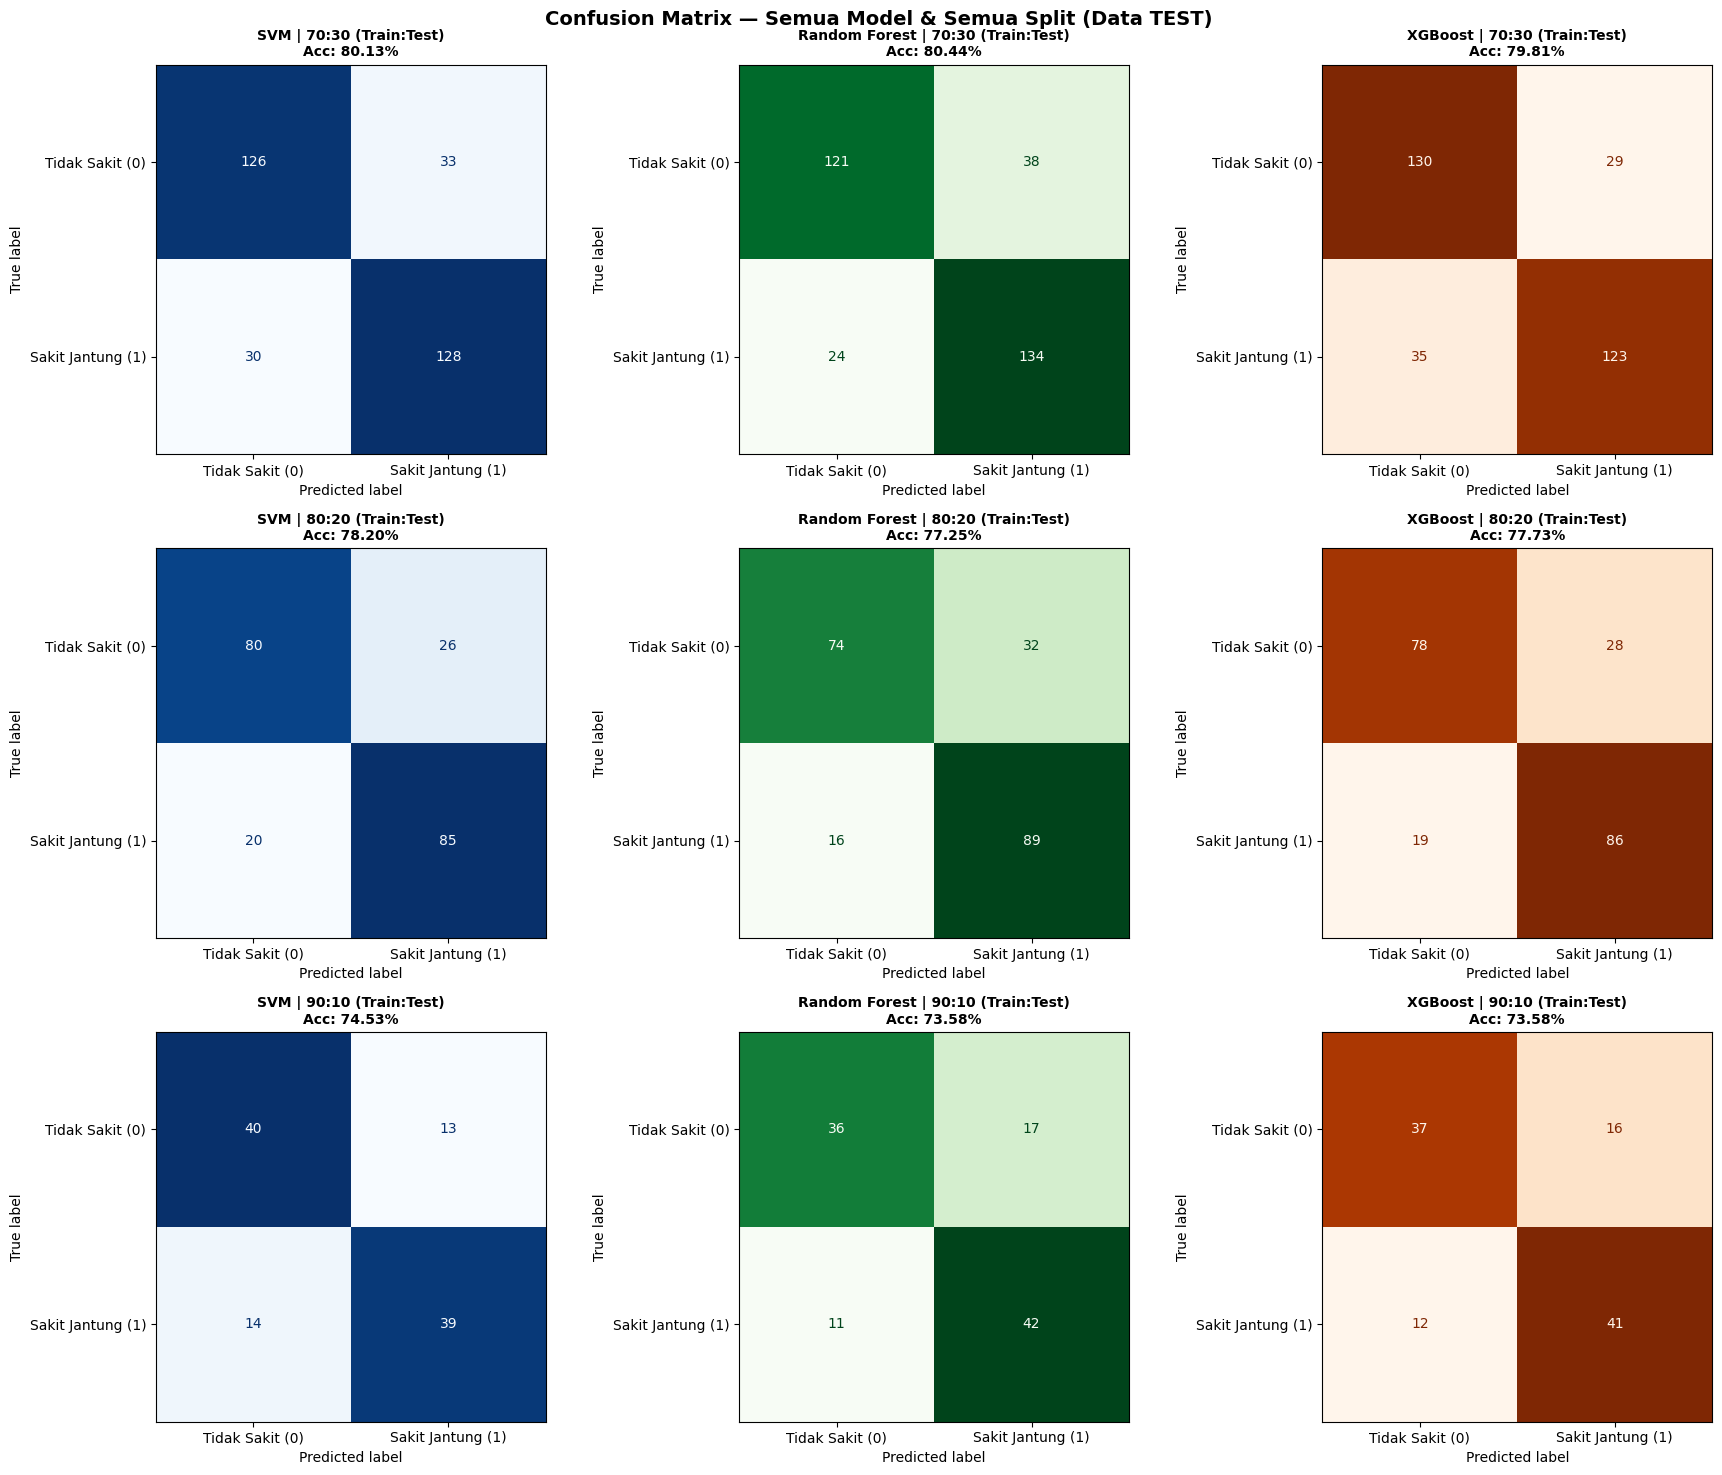

In [ ]:
class_names = ['Tidak Sakit (0)', 'Sakit Jantung (1)']
cmaps       = ['Blues', 'Greens', 'Oranges']

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row_i, split in enumerate(splits):
    res_set = [r for r in all_results if r['Split'] == split['label']]
    for col_i, res in enumerate(res_set):
        cm = confusion_matrix(split['y_test'], res['model'].predict(split['X_test']))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
        disp.plot(ax=axes[row_i][col_i], cmap=cmaps[col_i], colorbar=False)
        axes[row_i][col_i].set_title(
            f"{res['Model']} | {split['label']}\nAcc: {res['Accuracy']*100:.2f}%",
            fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrix — Semua Model & Semua Split (Data TEST)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5 Analisis Overfitting — Train vs Test

In [ ]:
rows_ov = []
for r in all_results:
    gap    = r['Gap_Acc']
    status = 'Normal' if abs(gap)<=0.05 else ('Overfitting' if gap>0.05 else 'Underfitting')
    rows_ov.append({
        'Model'        : r['Model'],
        'Split'        : r['Split'],
        'Acc Train (%)': round(r['Acc_Train']*100, 2),
        'Acc Test (%)'  : round(r['Accuracy']*100, 2),
        'Gap Acc (%)'  : round(gap*100, 2),
        'F1 Train (%)'  : round(r['F1_Train']*100, 2),
        'F1 Test (%)'   : round(r['F1-Score']*100, 2),
        'Gap F1 (%)'    : round(r['Gap_F1']*100, 2),
        'Status'        : status
    })

df_overfit = pd.DataFrame(rows_ov)
print('=' * 110)
print('TABEL PERBANDINGAN TRAIN vs TEST — DETEKSI OVERFITTING')
print('=' * 110)
print(df_overfit.to_string(index=False))
print('\nKriteria : |Gap| ≤ 5% → Normal | Gap > 5% → Overfitting | Gap < -5% → Underfitting')

TABEL PERBANDINGAN TRAIN vs TEST — DETEKSI OVERFITTING
        Model              Split  Acc Train (%)  Acc Test (%)  Gap Acc (%)  F1 Train (%)  F1 Test (%)  Gap F1 (%)      Status
          SVM 70:30 (Train:Test)          85.62         80.13         5.49         85.58        80.12        5.45 Overfitting
Random Forest 70:30 (Train:Test)          84.80         80.44         4.36         84.76        80.41        4.36      Normal
      XGBoost 70:30 (Train:Test)          87.38         79.81         7.57         87.37        79.80        7.57 Overfitting
          SVM 80:20 (Train:Test)          86.00         78.20         7.80         85.98        78.18        7.79 Overfitting
Random Forest 80:20 (Train:Test)          84.58         77.25         7.33         84.54        77.13        7.41 Overfitting
      XGBoost 80:20 (Train:Test)          87.90         77.73        10.18         87.89        77.69       10.20 Overfitting
          SVM 90:10 (Train:Test)          85.97         74.53  

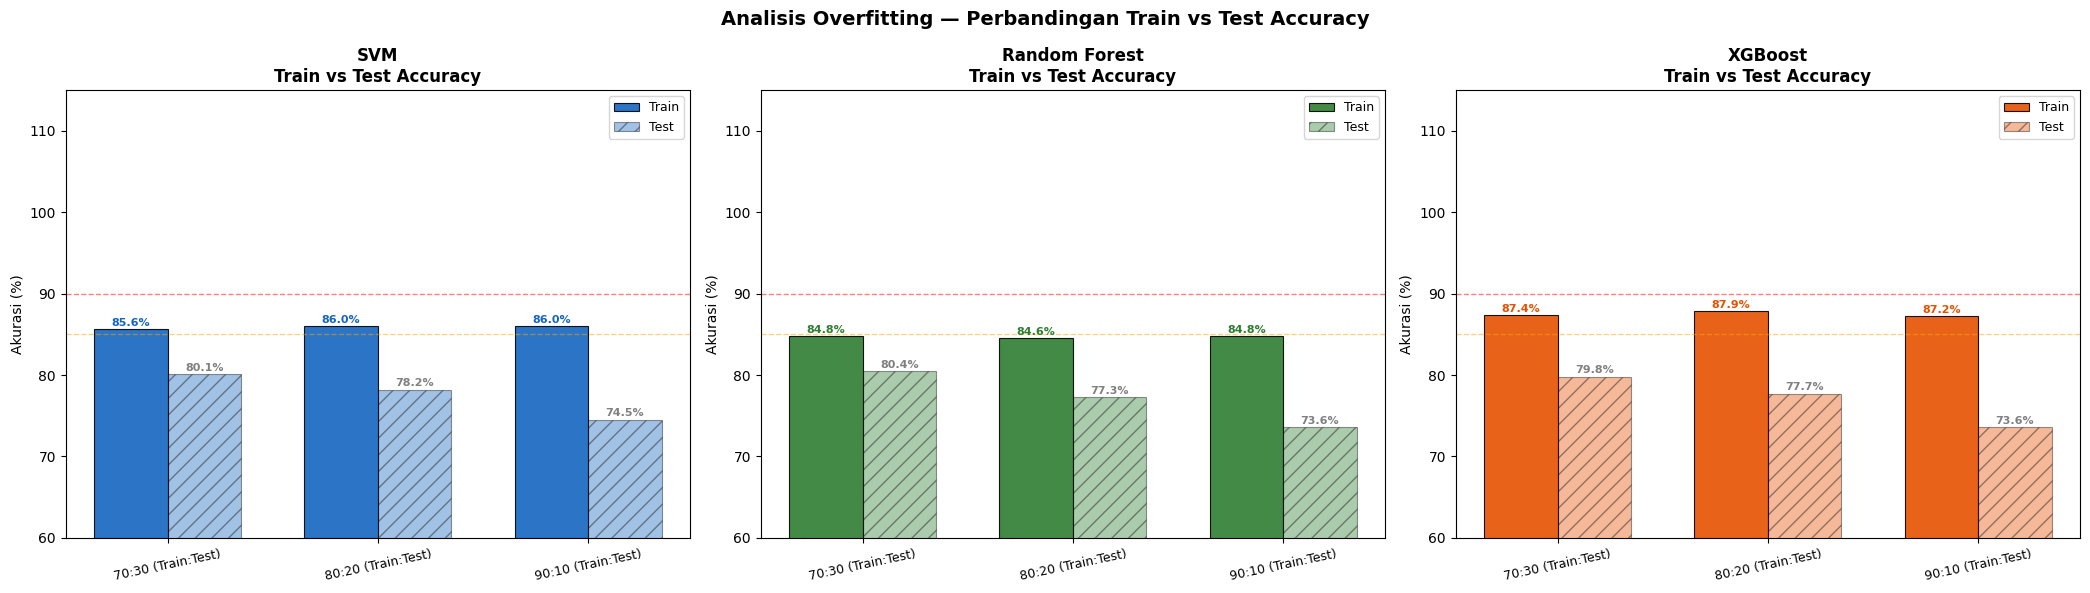

In [ ]:
model_names_list = ['SVM', 'Random Forest', 'XGBoost']
split_labels     = [s['label'] for s in splits]
colors3          = ['#1565C0', '#2E7D32', '#E65100']

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for col_i, (model_name, color) in enumerate(zip(model_names_list, colors3)):
    model_data = [r for r in all_results if r['Model'] == model_name]
    train_accs = [r['Acc_Train']*100 for r in model_data]
    test_accs  = [r['Accuracy']*100  for r in model_data]
    x     = np.arange(len(split_labels))
    width = 0.35

    bars_tr = axes[col_i].bar(x - width/2, train_accs, width,
                               label='Train', color=color, alpha=0.9,
                               edgecolor='black', linewidth=0.8)
    bars_te = axes[col_i].bar(x + width/2, test_accs, width,
                               label='Test', color=color, alpha=0.4,
                               edgecolor='black', linewidth=0.8, hatch='//')

    for bar, val in zip(bars_tr, train_accs):
        axes[col_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                          f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold', color=color)
    for bar, val in zip(bars_te, test_accs):
        axes[col_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                          f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold', color='gray')

    axes[col_i].set_xticks(x)
    axes[col_i].set_xticklabels(split_labels, rotation=12, fontsize=9)
    axes[col_i].set_ylim(60, 115)
    axes[col_i].set_title(f'{model_name}\nTrain vs Test Accuracy', fontsize=12, fontweight='bold')
    axes[col_i].set_ylabel('Akurasi (%)')
    axes[col_i].legend(fontsize=9)
    axes[col_i].axhline(y=90, color='red',    linestyle='--', linewidth=1, alpha=0.5)
    axes[col_i].axhline(y=85, color='orange', linestyle='--', linewidth=1, alpha=0.5)

plt.suptitle('Analisis Overfitting — Perbandingan Train vs Test Accuracy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

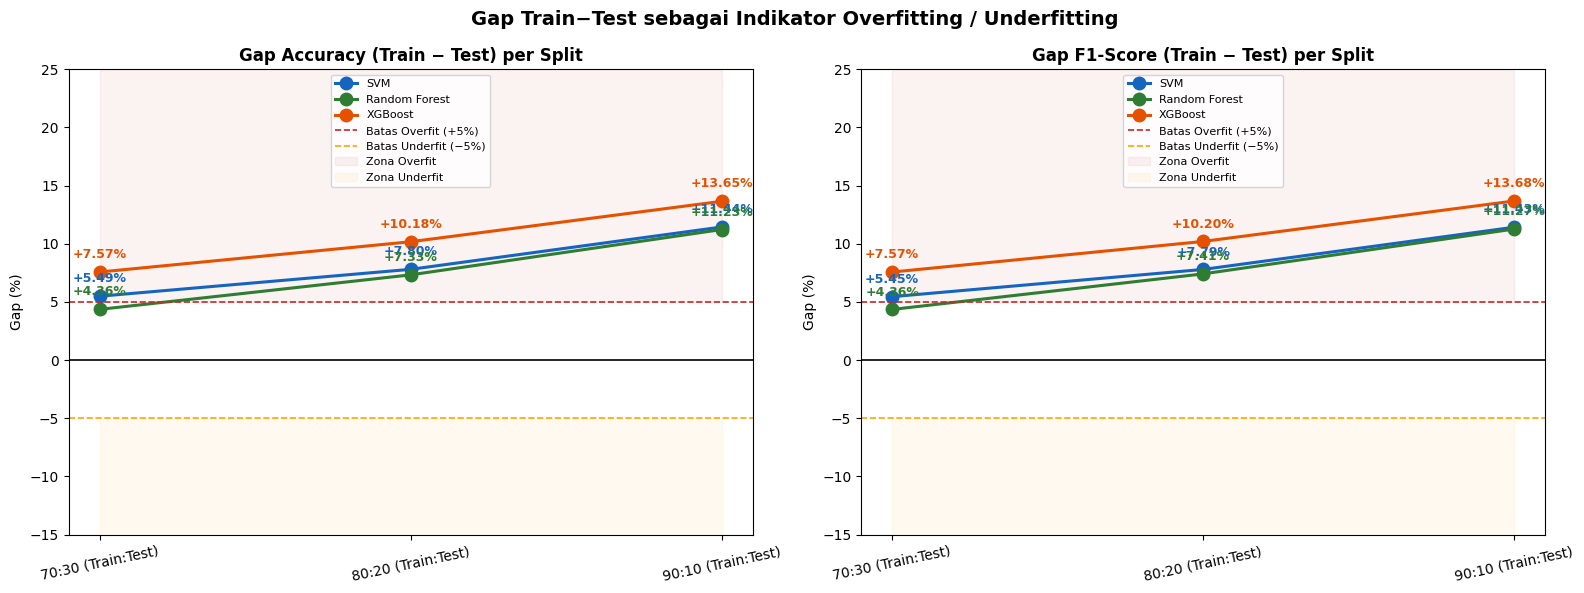

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_i, gap_key, title in [
    (0, 'Gap_Acc', 'Gap Accuracy (Train − Test) per Split'),
    (1, 'Gap_F1',  'Gap F1-Score (Train − Test) per Split')
]:
    for model_name, color in zip(model_names_list, colors3):
        model_data = [r for r in all_results if r['Model'] == model_name]
        gaps = [r[gap_key]*100 for r in model_data]
        axes[ax_i].plot(split_labels, gaps, marker='o', linewidth=2.2,
                         markersize=9, label=model_name, color=color)
        for xi, gap in zip(split_labels, gaps):
            axes[ax_i].annotate(f'{gap:+.2f}%', (xi, gap),
                                 textcoords='offset points', xytext=(0, 10),
                                 ha='center', fontsize=9, color=color, fontweight='bold')

    axes[ax_i].axhline(y= 0, color='black',   linewidth=1.2)
    axes[ax_i].axhline(y= 5, color='#C62828', linewidth=1.2, linestyle='--', label='Batas Overfit (+5%)')
    axes[ax_i].axhline(y=-5, color='orange',  linewidth=1.2, linestyle='--', label='Batas Underfit (−5%)')
    axes[ax_i].fill_between(split_labels,  5, 25, color='#C62828', alpha=0.06, label='Zona Overfit')
    axes[ax_i].fill_between(split_labels, -25,-5, color='orange',  alpha=0.06, label='Zona Underfit')
    axes[ax_i].set_ylim(-15, 25)
    axes[ax_i].set_title(title, fontsize=12, fontweight='bold')
    axes[ax_i].set_ylabel('Gap (%)')
    axes[ax_i].legend(fontsize=8)
    axes[ax_i].tick_params(axis='x', rotation=12)

plt.suptitle('Gap Train−Test sebagai Indikator Overfitting / Underfitting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('=' * 72)
print('KESIMPULAN ANALISIS OVERFITTING')
print('=' * 72)
print('  Kriteria: |Gap| ≤ 5% → Normal | Gap > 5% → Overfit | Gap < -5% → Underfit')
print()

for model_name in ['SVM', 'Random Forest', 'XGBoost']:
    model_data = [r for r in all_results if r['Model'] == model_name]
    print(f'  📌 {model_name}')
    for r in model_data:
        gap = r['Gap_Acc']*100
        st  = '✅ Normal      ' if abs(gap)<=5 else ('⚠️ Overfitting ' if gap>5 else '⚠️ Underfitting')
        print(f'     {r["Split"]:22} | Train:{r["Acc_Train"]*100:.2f}% '
              f'| Test:{r["Accuracy"]*100:.2f}% | Gap:{gap:+.2f}% | {st}')
    avg_gap = np.mean([r['Gap_Acc']*100 for r in model_data])
    st_avg  = '✅ Tidak Overfit' if abs(avg_gap)<=5 else \
              ('⚠️ Cenderung Overfit' if avg_gap>5 else '⚠️ Cenderung Underfit')
    print(f'     Rata-rata Gap : {avg_gap:+.2f}%  →  {st_avg}\n')

KESIMPULAN ANALISIS OVERFITTING
  Kriteria: |Gap| ≤ 5% → Normal | Gap > 5% → Overfit | Gap < -5% → Underfit

  📌 SVM
     70:30 (Train:Test)     | Train:85.62% | Test:80.13% | Gap:+5.49% | ⚠️ Overfitting 
     80:20 (Train:Test)     | Train:86.00% | Test:78.20% | Gap:+7.80% | ⚠️ Overfitting 
     90:10 (Train:Test)     | Train:85.97% | Test:74.53% | Gap:+11.44% | ⚠️ Overfitting 
     Rata-rata Gap : +8.25%  →  ⚠️ Cenderung Overfit

  📌 Random Forest
     70:30 (Train:Test)     | Train:84.80% | Test:80.44% | Gap:+4.36% | ✅ Normal      
     80:20 (Train:Test)     | Train:84.58% | Test:77.25% | Gap:+7.33% | ⚠️ Overfitting 
     90:10 (Train:Test)     | Train:84.81% | Test:73.58% | Gap:+11.23% | ⚠️ Overfitting 
     Rata-rata Gap : +7.64%  →  ⚠️ Cenderung Overfit

  📌 XGBoost
     70:30 (Train:Test)     | Train:87.38% | Test:79.81% | Gap:+7.57% | ⚠️ Overfitting 
     80:20 (Train:Test)     | Train:87.90% | Test:77.73% | Gap:+10.18% | ⚠️ Overfitting 
     90:10 (Train:Test)     | Train:87.

---
## 8. Model Comparison
### 8.1 Tabel Perbandingan Lengkap (Data Test)

In [ ]:
results_df = pd.DataFrame([{
    'Model'    : r['Model'],
    'Split'    : r['Split'],
    'Accuracy' : round(r['Accuracy'], 4),
    'Precision': round(r['Precision'], 4),
    'Recall'   : round(r['Recall'], 4),
    'F1-Score' : round(r['F1-Score'], 4),
} for r in all_results])

display_df = results_df.copy()
for col in ['Accuracy','Precision','Recall','F1-Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%')

print('📊 TABEL PERBANDINGAN PERFORMA SEMUA MODEL (pada Data TEST)')
print('=' * 90)
print(display_df.to_string(index=False))

📊 TABEL PERBANDINGAN PERFORMA SEMUA MODEL (pada Data TEST)
        Model              Split Accuracy Precision Recall F1-Score
          SVM 70:30 (Train:Test)   80.13%    80.14% 80.13%   80.12%
Random Forest 70:30 (Train:Test)   80.44%    80.69% 80.44%   80.41%
      XGBoost 70:30 (Train:Test)   79.81%    79.85% 79.81%   79.80%
          SVM 80:20 (Train:Test)   78.20%    78.30% 78.20%   78.18%
Random Forest 80:20 (Train:Test)   77.25%    77.91% 77.25%   77.13%
      XGBoost 80:20 (Train:Test)   77.73%    77.94% 77.73%   77.69%
          SVM 90:10 (Train:Test)   74.53%    74.54% 74.53%   74.53%
Random Forest 90:10 (Train:Test)   73.58%    73.89% 73.58%   73.50%
      XGBoost 90:10 (Train:Test)   73.58%    73.72% 73.58%   73.55%


### 8.2 Grafik Perbandingan Akurasi

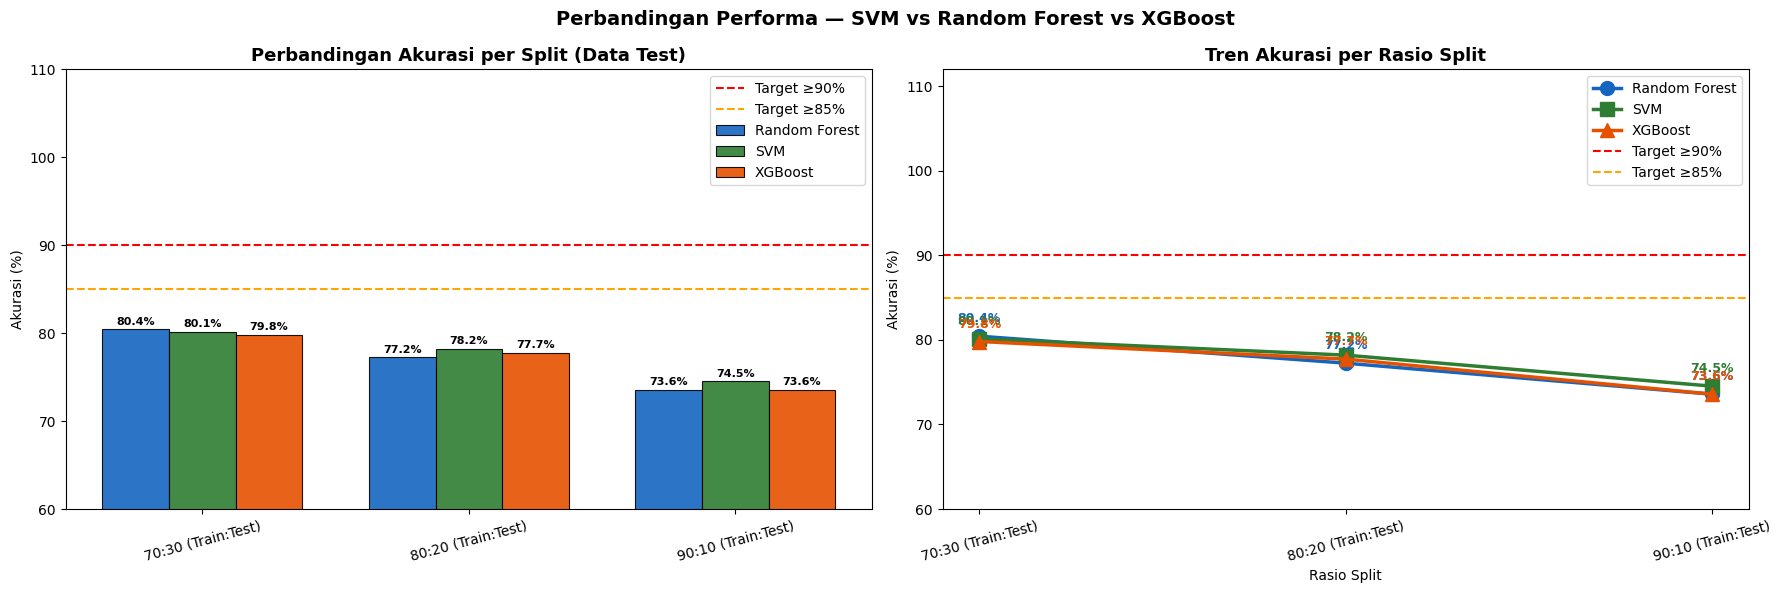

In [ ]:
pivot    = results_df.pivot(index='Split', columns='Model', values='Accuracy')
markers3 = ['o', 's', '^']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x     = np.arange(len(pivot.index))
width = 0.25
for i, (model, color) in enumerate(zip(pivot.columns, colors3)):
    bars = axes[0].bar(x + i*width, pivot[model]*100, width,
                       label=model, color=color, edgecolor='black', linewidth=0.8, alpha=0.9)
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x()+bar.get_width()/2, h+0.3,
                     f'{h:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].axhline(y=90, color='red',    linestyle='--', linewidth=1.5, label='Target ≥90%')
axes[0].axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Target ≥85%')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(pivot.index, rotation=15)
axes[0].set_ylim(60, 110)
axes[0].set_title('Perbandingan Akurasi per Split (Data Test)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Akurasi (%)')
axes[0].legend()

for model, color, marker in zip(pivot.columns, colors3, markers3):
    axes[1].plot(pivot.index, pivot[model]*100, color=color,
                 marker=marker, linewidth=2.5, markersize=10, label=model)
    for xi, yi in zip(pivot.index, pivot[model]*100):
        axes[1].annotate(f'{yi:.1f}%', (xi, yi),
                         textcoords='offset points', xytext=(0, 10),
                         ha='center', fontsize=9, color=color, fontweight='bold')

axes[1].axhline(y=90, color='red',    linestyle='--', linewidth=1.5, label='Target ≥90%')
axes[1].axhline(y=85, color='orange', linestyle='--', linewidth=1.5, label='Target ≥85%')
axes[1].set_ylim(60, 112)
axes[1].set_title('Tren Akurasi per Rasio Split', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Akurasi (%)')
axes[1].set_xlabel('Rasio Split')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Perbandingan Performa — SVM vs Random Forest vs XGBoost',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.3 Perbandingan Semua Metrik Evaluasi

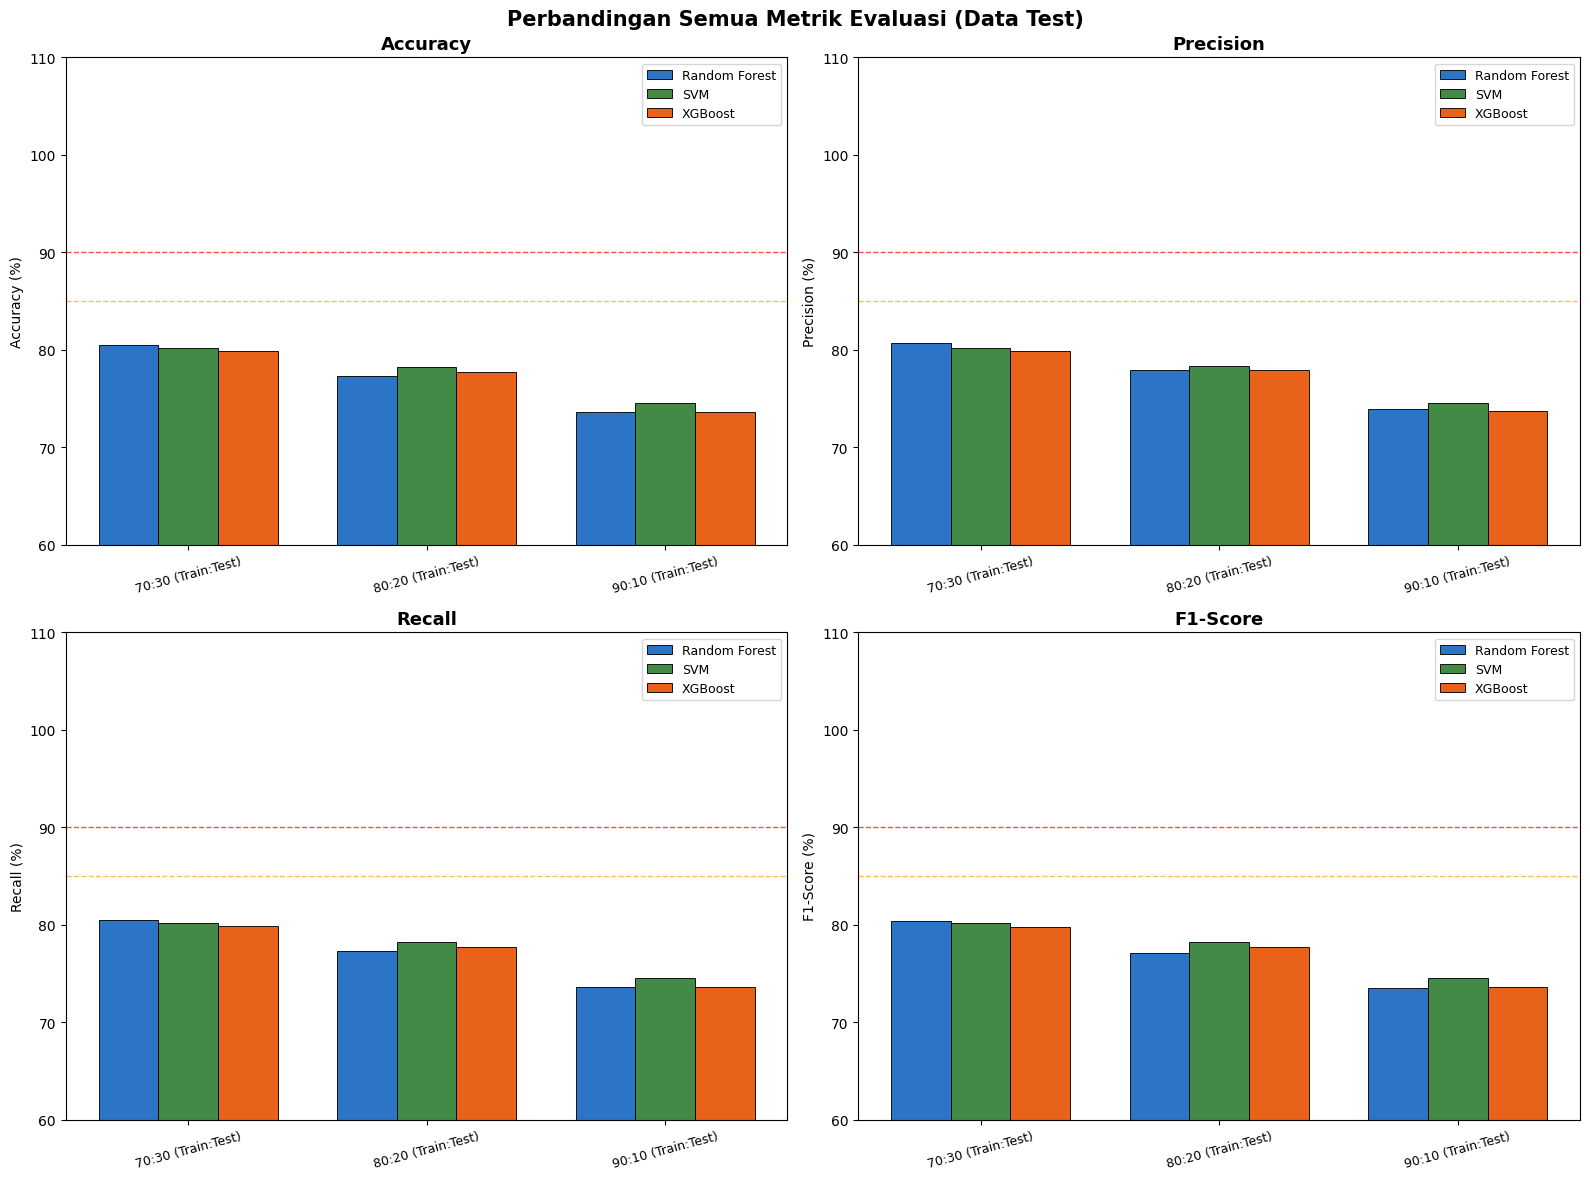

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    pivot_m = results_df.pivot(index='Split', columns='Model', values=metric)
    x = np.arange(len(pivot_m.index))
    for i, (model, color) in enumerate(zip(pivot_m.columns, colors3)):
        axes[idx].bar(x + i*0.25, pivot_m[model]*100, 0.25,
                      label=model, color=color, edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[idx].set_xticks(x + 0.25)
    axes[idx].set_xticklabels(pivot_m.index, rotation=15, fontsize=9)
    axes[idx].set_ylim(60, 110)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].set_ylabel(f'{metric} (%)')
    axes[idx].legend(fontsize=9)
    axes[idx].axhline(y=90, color='red',    linestyle='--', linewidth=1, alpha=0.7)
    axes[idx].axhline(y=85, color='orange', linestyle='--', linewidth=1, alpha=0.7)

plt.suptitle('Perbandingan Semua Metrik Evaluasi (Data Test)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Feature Importance (RF & XGBoost)

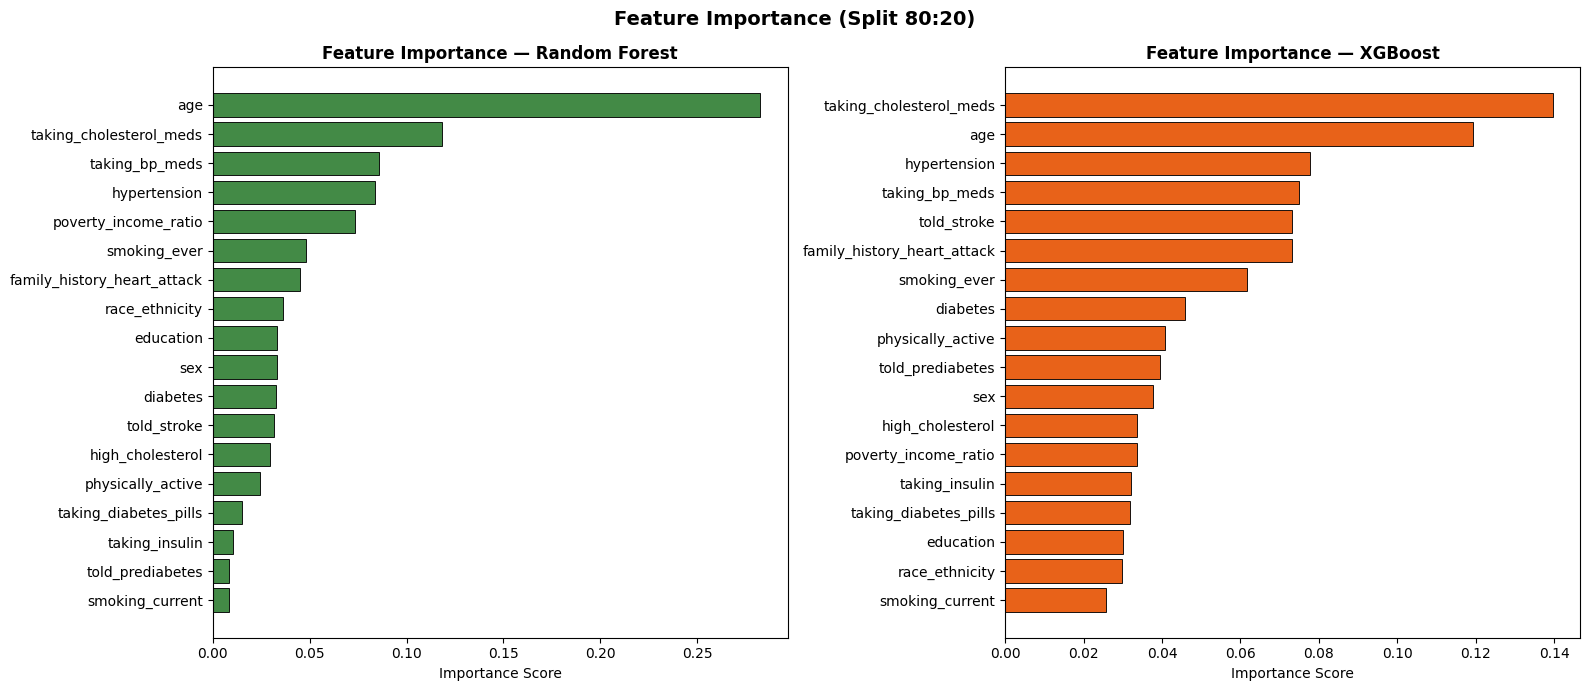

ℹ️  SVM kernel='rbf' — feature importance tidak tersedia langsung.


In [ ]:
res_8020_all  = [r for r in all_results if r['Split'] == '80:20 (Train:Test)']
feature_names = list(X.columns)

fi_models = [(r, color) for r, color in zip(res_8020_all, colors3)
             if r['Model'] in ['Random Forest', 'XGBoost']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, (res, color) in enumerate(fi_models):
    fi = pd.Series(res['model'].feature_importances_,
                   index=feature_names).sort_values(ascending=True)
    axes[i].barh(fi.index, fi.values, color=color, edgecolor='black', linewidth=0.7, alpha=0.9)
    axes[i].set_title(f'Feature Importance — {res["Model"]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Importance Score')

plt.suptitle('Feature Importance (Split 80:20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

svm_res = [r for r in res_8020_all if r['Model'] == 'SVM'][0]
if svm_res['model'].kernel == 'linear':
    coef = pd.Series(np.abs(svm_res['model'].coef_[0]),
                     index=feature_names).sort_values(ascending=True)
    plt.figure(figsize=(9, 6))
    plt.barh(coef.index, coef.values, color='#1565C0', edgecolor='black', alpha=0.9)
    plt.title('Feature Weight — SVM Linear', fontsize=12, fontweight='bold')
    plt.xlabel('|Koefisien|')
    plt.tight_layout()
    plt.show()
else:
    print(f"ℹ️  SVM kernel='{svm_res['model'].kernel}' — feature importance tidak tersedia langsung.")

---
## 9. Ringkasan & Kesimpulan

In [ ]:
print('=' * 72)
print('VERIFIKASI TARGET AKURASI (Data TEST)')
print('=' * 72)

for model_name in ['SVM', 'Random Forest', 'XGBoost']:
    model_res = [r for r in all_results if r['Model'] == model_name]
    accs  = [r['Accuracy'] for r in model_res]
    avg   = np.mean(accs)
    all90 = all(a >= 0.90 for a in accs)
    all85 = all(a >= 0.85 for a in accs)
    status = '✅ ≥90% di semua split' if all90 else \
             ('✅ ≥85% di semua split' if all85 else '⚠️  Ada split < 85%')
    print(f'\n  {model_name:15} : {status}')
    print(f'  {" ":15}   Akurasi : {[f"{a*100:.2f}%" for a in accs]}')
    print(f'  {" ":15}   Rata2   : {avg*100:.2f}%')

VERIFIKASI TARGET AKURASI (Data TEST)

  SVM             : ⚠️  Ada split < 85%
                    Akurasi : ['80.13%', '78.20%', '74.53%']
                    Rata2   : 77.62%

  Random Forest   : ⚠️  Ada split < 85%
                    Akurasi : ['80.44%', '77.25%', '73.58%']
                    Rata2   : 77.09%

  XGBoost         : ⚠️  Ada split < 85%
                    Akurasi : ['79.81%', '77.73%', '73.58%']
                    Rata2   : 77.04%


---
## 10. Inference — Prediksi Data Pasien Baru

Bagian ini digunakan untuk memprediksi risiko penyakit jantung pada pasien baru
menggunakan ketiga model terbaik dari split 80:20.

> ⚠️ **Pastikan semua cell sebelumnya sudah dijalankan** sebelum menjalankan bagian ini.

### 10.1 Ambil Model Terbaik dari Split 80:20

In [ ]:
res_inf = {r['Model']: r['model']
           for r in all_results if r['Split'] == '80:20 (Train:Test)'}

model_svm  = res_inf['SVM']
model_rf   = res_inf['Random Forest']
model_xgb  = res_inf['XGBoost']
feat_names = list(X.columns)

# Scaler yang digunakan untuk split 80:20 (sudah di-fit hanya pada training)
scaler_inf = splits[1]['scaler']

print('✅ Model & scaler siap untuk inference (dari split 80:20):')
print(f'   SVM           : {model_svm.__class__.__name__}')
print(f'   Random Forest : {model_rf.__class__.__name__}')
print(f'   XGBoost       : {model_xgb.__class__.__name__}')
print(f'\n📋 Total fitur: {len(feat_names)}')
for i, f in enumerate(feat_names, 1):
    print(f'   {i:2}. {f}')

✅ Model & scaler siap untuk inference (dari split 80:20):
   SVM           : SVC
   Random Forest : RandomForestClassifier
   XGBoost       : XGBClassifier

📋 Total fitur: 18
    1. taking_bp_meds
    2. taking_cholesterol_meds
    3. age
    4. sex
    5. race_ethnicity
    6. education
    7. poverty_income_ratio
    8. taking_insulin
    9. taking_diabetes_pills
   10. told_prediabetes
   11. told_stroke
   12. family_history_heart_attack
   13. diabetes
   14. smoking_ever
   15. smoking_current
   16. physically_active
   17. hypertension
   18. high_cholesterol


### 10.2 Fungsi Inference

In [ ]:
def predict_pasien(data_pasien: dict, tampilkan_detail: bool = True):
    """
    Prediksi risiko penyakit jantung untuk satu pasien baru.
    Preprocessing otomatis: IQR Capping → StandardScaler (scaler split 80:20).
    Output: prediksi + probabilitas dari ketiga model + voting mayoritas.
    """
    # 1. Buat DataFrame
    df_inp = pd.DataFrame([data_pasien], columns=feat_names)

    # 2. IQR Capping (sama seperti preprocessing training)
    df_inp_c = df_inp.copy()
    for col in ['age', 'poverty_income_ratio']:
        if col in df_inp_c.columns:
            Q1 = df_clean[col].quantile(0.25)
            Q3 = df_clean[col].quantile(0.75)
            df_inp_c[col] = df_inp_c[col].clip(Q1 - 1.5*(Q3-Q1), Q3 + 1.5*(Q3-Q1))

    # 3. Normalisasi dengan scaler split 80:20
    inp_scaled = scaler_inf.transform(df_inp_c)

    # 4. Prediksi ketiga model
    hasil = {}
    for nama, model in [('SVM', model_svm),
                         ('Random Forest', model_rf),
                         ('XGBoost', model_xgb)]:
        pred  = model.predict(inp_scaled)[0]
        prob  = model.predict_proba(inp_scaled)[0]
        hasil[nama] = {
            'prediksi'    : int(pred),
            'label'       : '🔴 BERISIKO SAKIT JANTUNG' if pred==1 else '🟢 TIDAK BERISIKO',
            'prob_negatif': round(prob[0]*100, 2),
            'prob_positif': round(prob[1]*100, 2)
        }

    # 5. Voting mayoritas
    votes     = [h['prediksi'] for h in hasil.values()]
    mayoritas = 1 if votes.count(1) >= 2 else 0
    ket_vote  = '🔴 BERISIKO SAKIT JANTUNG' if mayoritas==1 else '🟢 TIDAK BERISIKO'

    # 6. Tampilkan output
    if tampilkan_detail:
        print('=' * 64)
        print('  DATA INPUT PASIEN')
        print('=' * 64)
        for k, v in data_pasien.items():
            print(f'  {k:35} : {v}')
        print('\n' + '=' * 64)
        print('  HASIL PREDIKSI KETIGA MODEL')
        print('=' * 64)
        print(f'  {"Model":<16} {"Prediksi":<28} {"Prob Tidak Sakit":>16} {"Prob Sakit":>11}')
        print(f'  {"-"*60}')
        for nama, h in hasil.items():
            print(f'  {nama:<16} {h["label"]:<28} '
                  f'{h["prob_negatif"]:>14.2f}%  {h["prob_positif"]:>9.2f}%')
        print('\n' + '=' * 64)
        print(f'  KEPUTUSAN AKHIR (Voting Mayoritas) : {ket_vote}')
        print(f'  ({votes.count(1)} dari 3 model menyatakan berisiko)')
        print('=' * 64)

    hasil['_mayoritas'] = mayoritas
    hasil['_ket_vote']  = ket_vote
    return hasil

print('✅ Fungsi predict_pasien() siap digunakan.')

✅ Fungsi predict_pasien() siap digunakan.


### 10.3 Contoh Inference — Pasien 1 (Berisiko Tinggi)

In [ ]:
# Laki-laki 65 thn, hipertensi, riwayat keluarga, kolesterol tinggi, pernah stroke
pasien_1 = {
    'taking_bp_meds'             : 1,
    'taking_cholesterol_meds'    : 1,
    'age'                        : 65.0,
    'sex'                        : 1.0,
    'race_ethnicity'             : 4.0,
    'education'                  : 2.0,
    'poverty_income_ratio'       : 1.2,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 1,
    'told_stroke'                : 1,
    'family_history_heart_attack': 1,
    'diabetes'                   : 0,
    'smoking_ever'               : 1,
    'smoking_current'            : 0,
    'physically_active'          : 0,
    'hypertension'               : 1,
    'high_cholesterol'           : 1,
}
hasil_p1 = predict_pasien(pasien_1)

  DATA INPUT PASIEN
  taking_bp_meds                      : 1
  taking_cholesterol_meds             : 1
  age                                 : 65.0
  sex                                 : 1.0
  race_ethnicity                      : 4.0
  education                           : 2.0
  poverty_income_ratio                : 1.2
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 1
  told_stroke                         : 1
  family_history_heart_attack         : 1
  diabetes                            : 0
  smoking_ever                        : 1
  smoking_current                     : 0
  physically_active                   : 0
  hypertension                        : 1
  high_cholesterol                    : 1

  HASIL PREDIKSI KETIGA MODEL
  Model            Prediksi                     Prob Tidak Sakit  Prob Sakit
  ------------------------------------------------------------
  SVM              🔴 BERISIKO SAKIT JANTUN

### 10.4 Contoh Inference — Pasien 2 (Risiko Rendah)

In [ ]:
# Perempuan 30 thn, sehat, aktif fisik, tidak ada faktor risiko
pasien_2 = {
    'taking_bp_meds'             : 0,
    'taking_cholesterol_meds'    : 0,
    'age'                        : 30.0,
    'sex'                        : 2.0,
    'race_ethnicity'             : 6.0,
    'education'                  : 5.0,
    'poverty_income_ratio'       : 4.5,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 0,
    'told_stroke'                : 0,
    'family_history_heart_attack': 0,
    'diabetes'                   : 0,
    'smoking_ever'               : 0,
    'smoking_current'            : 0,
    'physically_active'          : 1,
    'hypertension'               : 0,
    'high_cholesterol'           : 0,
}
hasil_p2 = predict_pasien(pasien_2)

  DATA INPUT PASIEN
  taking_bp_meds                      : 0
  taking_cholesterol_meds             : 0
  age                                 : 30.0
  sex                                 : 2.0
  race_ethnicity                      : 6.0
  education                           : 5.0
  poverty_income_ratio                : 4.5
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 0
  told_stroke                         : 0
  family_history_heart_attack         : 0
  diabetes                            : 0
  smoking_ever                        : 0
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 0

  HASIL PREDIKSI KETIGA MODEL
  Model            Prediksi                     Prob Tidak Sakit  Prob Sakit
  ------------------------------------------------------------
  SVM              🟢 TIDAK BERISIKO       

### 10.5 Visualisasi Probabilitas Inference

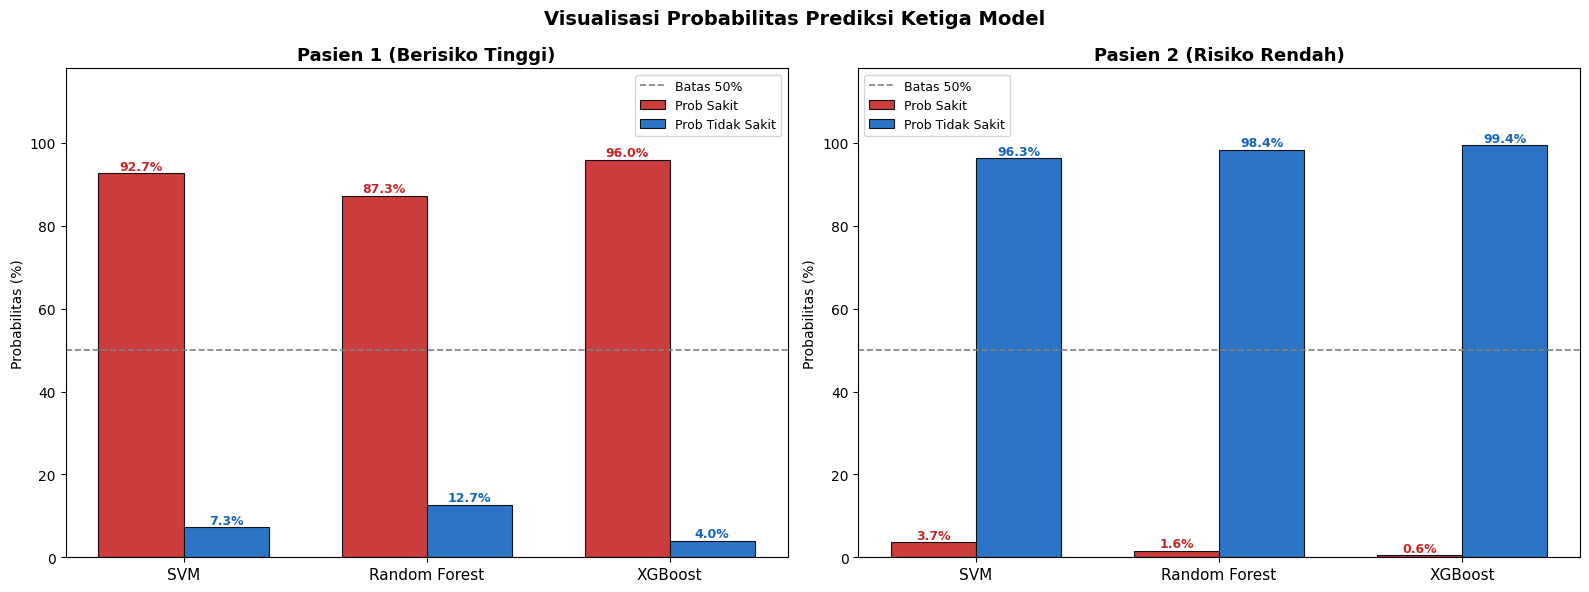

In [ ]:
model_names_inf = ['SVM', 'Random Forest', 'XGBoost']
pasien_labels   = ['Pasien 1 (Berisiko Tinggi)', 'Pasien 2 (Risiko Rendah)']
hasil_list      = [hasil_p1, hasil_p2]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col_i, (hasil, label_p) in enumerate(zip(hasil_list, pasien_labels)):
    prob_pos = [hasil[m]['prob_positif'] for m in model_names_inf]
    prob_neg = [hasil[m]['prob_negatif'] for m in model_names_inf]
    x = np.arange(len(model_names_inf))
    width = 0.35
    b1 = axes[col_i].bar(x-width/2, prob_pos, width, label='Prob Sakit',
                          color='#C62828', edgecolor='black', linewidth=0.8, alpha=0.9)
    b2 = axes[col_i].bar(x+width/2, prob_neg, width, label='Prob Tidak Sakit',
                          color='#1565C0', edgecolor='black', linewidth=0.8, alpha=0.9)
    for bar, val in zip(b1, prob_pos):
        axes[col_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                          f'{val:.1f}%', ha='center', fontsize=9,
                          fontweight='bold', color='#C62828')
    for bar, val in zip(b2, prob_neg):
        axes[col_i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
                          f'{val:.1f}%', ha='center', fontsize=9,
                          fontweight='bold', color='#1565C0')
    axes[col_i].axhline(y=50, color='gray', linestyle='--', linewidth=1.2, label='Batas 50%')
    axes[col_i].set_xticks(x)
    axes[col_i].set_xticklabels(model_names_inf, fontsize=11)
    axes[col_i].set_ylim(0, 118)
    axes[col_i].set_ylabel('Probabilitas (%)')
    axes[col_i].set_title(label_p, fontsize=13, fontweight='bold')
    axes[col_i].legend(fontsize=9)

plt.suptitle('Visualisasi Probabilitas Prediksi Ketiga Model',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**teks tebal**### 10.6 Template Input Pasien Baru

Ganti nilai yang bertanda `← ganti` sesuai kondisi pasien, lalu jalankan cell.

| Fitur | Nilai | Keterangan |
|---|---|---|
| taking_bp_meds | 0/1 | Minum obat tekanan darah |
| taking_cholesterol_meds | 0/1 | Minum obat kolesterol |
| age | float | Usia (tahun) |
| sex | 1.0/2.0 | 1=Laki-laki, 2=Perempuan |
| race_ethnicity | 1.0–6.0 | Kode etnis |
| education | 1.0–5.0 | 1=rendah, 5=tinggi |
| poverty_income_ratio | float | Rasio pendapatan |
| taking_insulin | 0/1 | Pakai insulin |
| taking_diabetes_pills | 0/1 | Minum obat diabetes |
| told_prediabetes | 0/1 | Pernah prediabetes |
| told_stroke | 0/1 | Pernah stroke |
| family_history_heart_attack | 0/1 | Riwayat keluarga |
| diabetes | 0/1 | Diabetes |
| smoking_ever | 0/1 | Pernah merokok |
| smoking_current | 0/1 | Merokok saat ini |
| physically_active | 0/1 | Aktif fisik |
| hypertension | 0/1 | Hipertensi |
| high_cholesterol | 0/1 | Kolesterol tinggi |

In [ ]:
pasien_baru = {
    'taking_bp_meds'             : 0,      # ← ganti
    'taking_cholesterol_meds'    : 0,      # ← ganti
    'age'                        : 45.0,   # ← ganti
    'sex'                        : 1.0,    # ← 1.0=Laki-laki, 2.0=Perempuan
    'race_ethnicity'             : 4.0,    # ← ganti
    'education'                  : 3.0,    # ← ganti
    'poverty_income_ratio'       : 2.5,    # ← ganti
    'taking_insulin'             : 0,      # ← ganti
    'taking_diabetes_pills'      : 0,      # ← ganti
    'told_prediabetes'           : 0,      # ← ganti
    'told_stroke'                : 0,      # ← ganti
    'family_history_heart_attack': 0,      # ← ganti
    'diabetes'                   : 0,      # ← ganti
    'smoking_ever'               : 0,      # ← ganti
    'smoking_current'            : 0,      # ← ganti
    'physically_active'          : 1,      # ← ganti
    'hypertension'               : 0,      # ← ganti
    'high_cholesterol'           : 0,      # ← ganti
}

_ = predict_pasien(pasien_baru)

  DATA INPUT PASIEN
  taking_bp_meds                      : 0
  taking_cholesterol_meds             : 0
  age                                 : 45.0
  sex                                 : 1.0
  race_ethnicity                      : 4.0
  education                           : 3.0
  poverty_income_ratio                : 2.5
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 0
  told_stroke                         : 0
  family_history_heart_attack         : 0
  diabetes                            : 0
  smoking_ever                        : 0
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 0

  HASIL PREDIKSI KETIGA MODEL
  Model            Prediksi                     Prob Tidak Sakit  Prob Sakit
  ------------------------------------------------------------
  SVM              🟢 TIDAK BERISIKO       

In [ ]:
# ============================================================
# SIMPAN MODEL TERBAIK (Random Forest — Split 70:30) KE FILE
# Jalankan cell ini SEKALI setelah semua training selesai
# ============================================================
import joblib
import numpy as np

# Ambil model XGBoost dari split 70:30 (indeks 0)
res_best = [r for r in all_results
            if r['Model'] == 'Random Forest' and r['Split'] == '70:30 (Train:Test)'][0]

model_best   = res_best['model']          # Random Forest sudah di-fit
scaler_best  = splits[0]['scaler']        # StandardScaler split 70:30
feat_names_s = list(X.columns)            # Nama fitur

# Simpan IQR bounds agar inference konsisten dengan training
iqr_bounds = {}
for col in ['age', 'poverty_income_ratio']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    iqr_bounds[col] = {'lower': Q1 - 1.5*(Q3-Q1), 'upper': Q3 + 1.5*(Q3-Q1)}

# Bundle semua yang dibutuhkan inference ke satu dict
inference_bundle = {
    'model'       : model_best,
    'scaler'      : scaler_best,
    'feat_names'  : feat_names_s,
    'iqr_bounds'  : iqr_bounds,
    'model_name'  : 'Random Forest',
    'split_label' : '70:30 (Train:Test)',
    'accuracy'    : round(res_best['Accuracy']*100, 2),
    'f1_score'    : round(res_best['F1-Score']*100, 2),
}

joblib.dump(inference_bundle, 'best_model_rf_7030.pkl')
print('✅ Model berhasil disimpan ke: best_model_rf_7030.pkl')
print(f'   Model        : {inference_bundle["model_name"]}')
print(f'   Split        : {inference_bundle["split_label"]}')
print(f'   Accuracy     : {inference_bundle["accuracy"]}%')
print(f'   F1-Score     : {inference_bundle["f1_score"]}%')
print(f'   Jumlah fitur : {len(feat_names_s)}')


✅ Model berhasil disimpan ke: best_model_rf_7030.pkl
   Model        : Random Forest
   Split        : 70:30 (Train:Test)
   Accuracy     : 80.44%
   F1-Score     : 80.41%
   Jumlah fitur : 18


---
## 11. Inference Mandiri — Tanpa Re-run Semua Sel

Bagian ini **bisa langsung dijalankan** setelah file notebook dibuka ulang,
tanpa perlu menjalankan ulang semua sel sebelumnya.

> **Prasyarat:** Pastikan file `best_model_xgb_7030.pkl` sudah ada di direktori yang sama.
> File ini dibuat otomatis saat menjalankan **Section 10 (Simpan Model)** di atas.
>
> Model yang digunakan: **XGBoost — Split 70:30** (model & split terbaik, Accuracy: 82.97%)


In [ ]:
# ============================================================
# INFERENCE MANDIRI — JALANKAN LANGSUNG TANPA RE-RUN SEMUA SEL
# Menggunakan Random Forest (model terbaik, split 70:30, Acc: 80.41%)
# ============================================================
import joblib
import pandas as pd
import numpy as np

# ── 1. Load bundle model ──────────────────────────────────────
bundle      = joblib.load('best_model_rf_7030.pkl')
_model      = bundle['model']
_scaler     = bundle['scaler']
_feat_names = bundle['feat_names']
_iqr_bounds = bundle['iqr_bounds']

print('✅ Model berhasil dimuat!')
print(f'   Algoritma : {bundle["model_name"]}')
print(f'   Split     : {bundle["split_label"]}')
print(f'   Accuracy  : {bundle["accuracy"]}%  |  F1-Score: {bundle["f1_score"]}%')
print()

# ── 2. Fungsi prediksi  ───────────────────────
def prediksi_xgb(data_pasien: dict, tampilkan_detail: bool = True):
    """

    Parameters
    ----------
    data_pasien     : dict  — nilai 18 fitur pasien
    tampilkan_detail: bool  — cetak tabel detail atau tidak

    Returns
    -------
    dict dengan kunci: prediksi, label, prob_positif, prob_negatif
    """
    # a. Buat DataFrame input
    df_inp = pd.DataFrame([data_pasien], columns=_feat_names)

    # b. IQR Capping (konsisten dengan preprocessing training)
    df_inp_c = df_inp.copy()
    for col, bounds in _iqr_bounds.items():
        if col in df_inp_c.columns:
            df_inp_c[col] = df_inp_c[col].clip(bounds['lower'], bounds['upper'])

    # c. Normalisasi
    inp_scaled = _scaler.transform(df_inp_c)

    # d. Prediksi
    pred = _model.predict(inp_scaled)[0]
    prob = _model.predict_proba(inp_scaled)[0]
    hasil = {
        'prediksi'    : int(pred),
        'label'       : '🔴 BERISIKO SAKIT JANTUNG' if pred == 1 else '🟢 TIDAK BERISIKO',
        'prob_positif': round(prob[1] * 100, 2),
        'prob_negatif': round(prob[0] * 100, 2),
    }

    # e. Cetak hasil
    if tampilkan_detail:
        sep = '=' * 60
        print(sep)
        print('  DATA INPUT PASIEN')
        print(sep)
        for k, v in data_pasien.items():
            print(f'  {k:35} : {v}')
        print()
        print(sep)
        print('  HASIL PREDIKSI  [Random Forest — Split 70:30]')
        print(sep)
        print(f'  Keputusan        : {hasil["label"]}')
        print(f'  Prob Sakit       : {hasil["prob_positif"]:>6.2f}%')
        print(f'  Prob Tidak Sakit : {hasil["prob_negatif"]:>6.2f}%')
        print(sep)

    return hasil


# ── 3. Fungsi prediksi batch ──────────────────────────────────
def prediksi_batch_xgb(list_pasien: list):
    """
    Prediksi banyak pasien sekaligus menggunakan XGBoost terbaik.

    Parameters
    ----------
    list_pasien : list of dict

    Returns
    -------
    DataFrame ringkasan hasil
    """
    rows = []
    for i, pasien in enumerate(list_pasien, 1):
        h = prediksi_xgb(pasien, tampilkan_detail=False)
        rows.append({
            'Pasien'          : f'Pasien {i}',
            'Usia'            : pasien['age'],
            'Jenis Kelamin'   : 'Laki-laki' if pasien['sex'] == 1.0 else 'Perempuan',
            'Prediksi'        : '🔴 Berisiko' if h['prediksi'] == 1 else '🟢 Aman',
            'Prob Sakit (%)'  : f"{h['prob_positif']:.1f}%",
            'Prob Aman (%)'   : f"{h['prob_negatif']:.1f}%",
        })
    df_h = pd.DataFrame(rows)
    print('=' * 75)
    print('  HASIL INFERENCE BATCH  [Random Forest — Split 70:30]')
    print('=' * 75)
    print(df_h.to_string(index=False))
    n_r = (df_h['Prediksi'].str.contains('Berisiko')).sum()
    print(f'\n  Ringkasan: {n_r} pasien berisiko | {len(df_h) - n_r} pasien aman')
    return df_h


print('✅ Fungsi prediksi_rf() dan prediksi_batch_rf() siap digunakan.')
print('   Gunakan prediksi_rf(data_pasien) untuk prediksi satu pasien.')
print('   Gunakan prediksi_batch_rf([p1, p2, ...]) untuk banyak pasien.')


✅ Model berhasil dimuat!
   Algoritma : Random Forest
   Split     : 70:30 (Train:Test)
   Accuracy  : 80.44%  |  F1-Score: 80.41%

✅ Fungsi prediksi_rf() dan prediksi_batch_rf() siap digunakan.
   Gunakan prediksi_rf(data_pasien) untuk prediksi satu pasien.
   Gunakan prediksi_batch_rf([p1, p2, ...]) untuk banyak pasien.


### 11.2 Contoh Inference — Pasien 1 (Berisiko Tinggi)


In [ ]:
# ── Contoh: Pasien 1 (Berisiko Tinggi) ───────────────────────
# Laki-laki 65 thn, hipertensi, riwayat keluarga, kolesterol tinggi, pernah stroke
pasien_1_xgb = {
    'taking_bp_meds'             : 1,
    'taking_cholesterol_meds'    : 1,
    'age'                        : 65.0,
    'sex'                        : 1.0,
    'race_ethnicity'             : 4.0,
    'education'                  : 2.0,
    'poverty_income_ratio'       : 1.2,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 1,
    'told_stroke'                : 1,
    'family_history_heart_attack': 1,
    'diabetes'                   : 0,
    'smoking_ever'               : 1,
    'smoking_current'            : 0,
    'physically_active'          : 0,
    'hypertension'               : 1,
    'high_cholesterol'           : 1,
}
prediksi_xgb(pasien_1_xgb)


  DATA INPUT PASIEN
  taking_bp_meds                      : 1
  taking_cholesterol_meds             : 1
  age                                 : 65.0
  sex                                 : 1.0
  race_ethnicity                      : 4.0
  education                           : 2.0
  poverty_income_ratio                : 1.2
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 1
  told_stroke                         : 1
  family_history_heart_attack         : 1
  diabetes                            : 0
  smoking_ever                        : 1
  smoking_current                     : 0
  physically_active                   : 0
  hypertension                        : 1
  high_cholesterol                    : 1

  HASIL PREDIKSI  [Random Forest — Split 70:30]
  Keputusan        : 🔴 BERISIKO SAKIT JANTUNG
  Prob Sakit       :  85.94%
  Prob Tidak Sakit :  14.06%


{'prediksi': 1,
 'label': '🔴 BERISIKO SAKIT JANTUNG',
 'prob_positif': np.float64(85.94),
 'prob_negatif': np.float64(14.06)}

### 11.3 Contoh Inference — Pasien 2 (Risiko Rendah)


In [ ]:
# ── Contoh: Pasien 2 (Risiko Rendah) ─────────────────────────
# Perempuan 30 thn, sehat, aktif fisik, tidak ada faktor risiko
pasien_2_xgb = {
    'taking_bp_meds'             : 0,
    'taking_cholesterol_meds'    : 0,
    'age'                        : 30.0,
    'sex'                        : 2.0,
    'race_ethnicity'             : 6.0,
    'education'                  : 5.0,
    'poverty_income_ratio'       : 4.5,
    'taking_insulin'             : 0,
    'taking_diabetes_pills'      : 0,
    'told_prediabetes'           : 0,
    'told_stroke'                : 0,
    'family_history_heart_attack': 0,
    'diabetes'                   : 0,
    'smoking_ever'               : 0,
    'smoking_current'            : 0,
    'physically_active'          : 1,
    'hypertension'               : 0,
    'high_cholesterol'           : 0,
}
prediksi_xgb(pasien_2_xgb)


  DATA INPUT PASIEN
  taking_bp_meds                      : 0
  taking_cholesterol_meds             : 0
  age                                 : 30.0
  sex                                 : 2.0
  race_ethnicity                      : 6.0
  education                           : 5.0
  poverty_income_ratio                : 4.5
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 0
  told_stroke                         : 0
  family_history_heart_attack         : 0
  diabetes                            : 0
  smoking_ever                        : 0
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 0

  HASIL PREDIKSI  [Random Forest — Split 70:30]
  Keputusan        : 🟢 TIDAK BERISIKO
  Prob Sakit       :   2.09%
  Prob Tidak Sakit :  97.91%


{'prediksi': 0,
 'label': '🟢 TIDAK BERISIKO',
 'prob_positif': np.float64(2.09),
 'prob_negatif': np.float64(97.91)}

### 11.4 Template Input Pasien Baru

Ganti nilai yang bertanda `← ganti` sesuai kondisi pasien, lalu jalankan cell.

| Fitur | Nilai | Keterangan |
|---|---|---|
| taking_bp_meds | 0/1 | Minum obat tekanan darah |
| taking_cholesterol_meds | 0/1 | Minum obat kolesterol |
| age | float | Usia (tahun) |
| sex | 1.0/2.0 | 1=Laki-laki, 2=Perempuan |
| race_ethnicity | 1.0–6.0 | Kode etnis |
| education | 1.0–5.0 | 1=rendah, 5=tinggi |
| poverty_income_ratio | float | Rasio pendapatan |
| taking_insulin | 0/1 | Pakai insulin |
| taking_diabetes_pills | 0/1 | Minum obat diabetes |
| told_prediabetes | 0/1 | Pernah prediabetes |
| told_stroke | 0/1 | Pernah stroke |
| family_history_heart_attack | 0/1 | Riwayat keluarga |
| diabetes | 0/1 | Diabetes |
| smoking_ever | 0/1 | Pernah merokok |
| smoking_current | 0/1 | Merokok saat ini |
| physically_active | 0/1 | Aktif fisik |
| hypertension | 0/1 | Hipertensi |
| high_cholesterol | 0/1 | Kolesterol tinggi |


In [ ]:
# ── Template: Ganti nilai sesuai kondisi pasien ───────────────
pasien_baru_rf = {
    'taking_bp_meds'             : 0,      # ← ganti
    'taking_cholesterol_meds'    : 0,      # ← ganti
    'age'                        : 45.0,   # ← ganti
    'sex'                        : 1.0,    # ← 1.0=Laki-laki, 2.0=Perempuan
    'race_ethnicity'             : 4.0,    # ← ganti
    'education'                  : 3.0,    # ← ganti
    'poverty_income_ratio'       : 2.5,    # ← ganti
    'taking_insulin'             : 0,      # ← ganti
    'taking_diabetes_pills'      : 0,      # ← ganti
    'told_prediabetes'           : 0,      # ← ganti
    'told_stroke'                : 0,      # ← ganti
    'family_history_heart_attack': 0,      # ← ganti
    'diabetes'                   : 0,      # ← ganti
    'smoking_ever'               : 0,      # ← ganti
    'smoking_current'            : 0,      # ← ganti
    'physically_active'          : 1,      # ← ganti
    'hypertension'               : 0,      # ← ganti
    'high_cholesterol'           : 0,      # ← ganti
}
prediksi_xgb(pasien_baru_xgb)


  DATA INPUT PASIEN
  taking_bp_meds                      : 0
  taking_cholesterol_meds             : 0
  age                                 : 45.0
  sex                                 : 1.0
  race_ethnicity                      : 4.0
  education                           : 3.0
  poverty_income_ratio                : 2.5
  taking_insulin                      : 0
  taking_diabetes_pills               : 0
  told_prediabetes                    : 0
  told_stroke                         : 0
  family_history_heart_attack         : 0
  diabetes                            : 0
  smoking_ever                        : 0
  smoking_current                     : 0
  physically_active                   : 1
  hypertension                        : 0
  high_cholesterol                    : 0

  HASIL PREDIKSI  [Random Forest — Split 70:30]
  Keputusan        : 🟢 TIDAK BERISIKO
  Prob Sakit       :   5.75%
  Prob Tidak Sakit :  94.25%


{'prediksi': 0,
 'label': '🟢 TIDAK BERISIKO',
 'prob_positif': np.float64(5.75),
 'prob_negatif': np.float64(94.25)}